In [1]:
import pandas as pd
from pathlib import Path
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

# Đường dẫn thư mục data
DATA_DIR = Path(r"D:\data_driven_marketing\data")

# Import 1 file .pkl
full_df = pd.read_pickle(DATA_DIR / "full_df_preprocessed.pkl")

# Kiểm tra nhanh
print("full_df shape:", full_df.shape)

print("\nFull df columns:")
print(full_df.columns.tolist())

display(full_df.head())

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
Pandas: 3.0.2
full_df shape: (1623718, 53)

Full df columns:
['channelGrouping', 'date', 'fullVisitorId', 'visitId', 'visitNumber', 'visitStartTime', 'device_browser', 'device_operatingSystem', 'device_isMobile', 'device_deviceCategory', 'geoNetwork_continent', 'geoNetwork_subContinent', 'geoNetwork_country', 'geoNetwork_region', 'geoNetwork_metro', 'geoNetwork_city', 'totals_visits', 'totals_hits', 'totals_pageviews', 'totals_bounces', 'totals_newVisits', 'totals_sessionQualityDim', 'totals_timeOnSite', 'totals_transactions', 'totals_transactionRevenue', 'totals_totalTransactionRevenue', 'trafficSource_campaign', 'trafficSource_source', 'trafficSource_medium', 'trafficSource_isTrueDirect', 'trafficSource_adwordsClickInfo.page', 'trafficSource_adwordsClickInfo.isVideoAd', 'customDimensions_count', 'customDimensions_index', 'customDimensions_value', 'Date_Year', 'Date_Month', 'Date_Day', 'Date_Dayof

,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue,network_type
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0,Other_International
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0,Other_International
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0,Home_ISP
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0,Other_International
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0,Other_International


In [2]:
# ============================================================
# CREATE USER-LEVEL FEATURES FOR K-MEANS FROM full_df
# No train/val/test split
# No target leakage
# Input : full_df_preprocessed.pkl
# Output: all_seg
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 0. Basic checks and type fixing
# ============================================================

df = full_df.copy()

# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# If date is originally YYYYMMDD integer/string, use this instead if needed:
# df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")

# Make sure ID is string
df["fullVisitorId"] = df["fullVisitorId"].astype(str)

# Numeric columns
numeric_cols = [
    "visitId",
    "visitNumber",
    "totals_visits",
    "totals_hits",
    "totals_pageviews",
    "totals_bounces",
    "totals_newVisits",
    "totals_sessionQualityDim",
    "totals_timeOnSite",
    "totals_transactions",
    "totals_transactionRevenue",
    "totals_totalTransactionRevenue",
    "transactionRevenue",
    "transactionRevenue_dollar",
    "Date_Dayofweek",
    "Date_Hour",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill important numeric columns
fill_zero_cols = [
    "totals_hits",
    "totals_pageviews",
    "totals_bounces",
    "totals_newVisits",
    "totals_sessionQualityDim",
    "totals_timeOnSite",
    "totals_transactions",
    "transactionRevenue",
]

for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# If transactionRevenue does not exist or is empty, rebuild from totals_transactionRevenue
if "transactionRevenue" not in df.columns:
    df["transactionRevenue"] = 0.0

if df["transactionRevenue"].isna().all() or df["transactionRevenue"].sum() == 0:
    if "totals_transactionRevenue" in df.columns:
        df["transactionRevenue"] = df["totals_transactionRevenue"].fillna(0)

# Safety
df["transactionRevenue"] = pd.to_numeric(df["transactionRevenue"], errors="coerce").fillna(0)

print("Session-level df shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique users:", df["fullVisitorId"].nunique())
print("Revenue sessions:", (df["transactionRevenue"] > 0).sum())

Session-level df shape: (1623718, 53)
Date range: 2016-08-01 00:00:00 to 2018-04-30 00:00:00
Unique users: 1272948
Revenue sessions: 16440


In [3]:
# ============================================================
# 1. USER-LEVEL AGGREGATION
# ============================================================

# Observation end date for recency calculation
feature_end_date = df["date"].max() + pd.Timedelta(days=1)

# ----------------------------
# 1.1 Diversity features
# ----------------------------

diversity_cols = [
    "geoNetwork_city",
    "geoNetwork_country",
    "trafficSource_source",
    "trafficSource_medium",
    "channelGrouping",
    "device_browser",
    "device_operatingSystem",
]

diversity_cols = [c for c in diversity_cols if c in df.columns]

diversity_df = (
    df.groupby("fullVisitorId")
    .agg({col: pd.Series.nunique for col in diversity_cols})
    .rename(columns={
        "geoNetwork_city": "city_nunique",
        "geoNetwork_country": "country_nunique",
        "trafficSource_source": "source_nunique",
        "trafficSource_medium": "medium_nunique",
        "channelGrouping": "channel_nunique",
        "device_browser": "browser_nunique",
        "device_operatingSystem": "os_nunique",
    })
    .reset_index()
)

diversity_feature_cols = [
    "city_nunique",
    "country_nunique",
    "source_nunique",
    "medium_nunique",
    "channel_nunique",
    "browser_nunique",
    "os_nunique",
]

diversity_feature_cols = [c for c in diversity_feature_cols if c in diversity_df.columns]

diversity_df["diversity_score"] = diversity_df[diversity_feature_cols].sum(axis=1)


# ----------------------------
# 1.2 Main user-level aggregation
# ----------------------------

agg_dict = {
    # Frequency
    "visitId": ["count", "nunique"],
    "visitNumber": "max",

    # Engagement
    "totals_hits": ["sum", "mean", "max"],
    "totals_pageviews": ["sum", "mean", "max"],
    "totals_timeOnSite": ["sum", "mean", "max"],
    "totals_bounces": "mean",
    "totals_sessionQualityDim": ["mean", "max"],

    # Monetary
    "transactionRevenue": ["sum", "mean", "max"],
    "totals_transactions": "sum",

    # Device
    "device_isMobile": "mean",
}

# Keep only existing columns
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

X_user = df.groupby("fullVisitorId").agg(agg_dict)

# Flatten columns
X_user.columns = [
    "_".join(str(c) for c in col).strip("_")
    for col in X_user.columns
]

X_user = X_user.reset_index()

# Rename important columns
rename_map = {
    "visitId_count": "visitId_count",
    "visitId_nunique": "visitId_nunique",
    "transactionRevenue_sum": "transactionRevenue_sum",
    "transactionRevenue_mean": "transactionRevenue_mean",
    "transactionRevenue_max": "transactionRevenue_max",
}

X_user = X_user.rename(columns=rename_map)

# Funnel proxy
# In your old code, funnel_depth was renamed from totals_hits_mean.
# But more intuitive is to keep totals_hits_mean and also create funnel_depth.
if "totals_hits_mean" in X_user.columns:
    X_user["funnel_depth"] = X_user["totals_hits_mean"]


# ----------------------------
# 1.3 Named time behavior aggregations
# ----------------------------

named_aggs = {}

if "Date_Dayofweek" in df.columns:
    named_aggs["pct_weekend"] = pd.NamedAgg(
        column="Date_Dayofweek",
        aggfunc=lambda x: (x >= 5).mean()
    )

if "Date_Hour" in df.columns:
    named_aggs["pct_evening"] = pd.NamedAgg(
        column="Date_Hour",
        aggfunc=lambda x: (x >= 20).mean()
    )

if len(named_aggs) > 0:
    X_named = df.groupby("fullVisitorId").agg(**named_aggs).reset_index()
    X_user = X_user.merge(X_named, on="fullVisitorId", how="left")
else:
    X_user["pct_weekend"] = 0.0
    X_user["pct_evening"] = 0.0


# ----------------------------
# 1.4 Merge diversity
# ----------------------------

X_user = X_user.merge(diversity_df, on="fullVisitorId", how="left")

for col in diversity_feature_cols + ["diversity_score"]:
    if col in X_user.columns:
        X_user[col] = X_user[col].fillna(0)


# ----------------------------
# 1.5 Recency, lifetime, visit stats
# ----------------------------

visit_stats = (
    df.groupby("fullVisitorId")
    .agg(
        first_visit_date=("date", "min"),
        last_visit_date=("date", "max"),
        visit_count=("visitId", "count"),
    )
    .reset_index()
)

visit_stats["recency_days"] = (
    feature_end_date - visit_stats["last_visit_date"]
).dt.days

visit_stats["lifetime_days"] = (
    visit_stats["last_visit_date"] - visit_stats["first_visit_date"]
).dt.days

X_user = X_user.merge(
    visit_stats[
        [
            "fullVisitorId",
            "first_visit_date",
            "last_visit_date",
            "recency_days",
            "lifetime_days",
            "visit_count",
        ]
    ],
    on="fullVisitorId",
    how="left"
)


# ----------------------------
# 1.6 Hibernation flag
# ----------------------------

repeat_users = visit_stats[visit_stats["visit_count"] > 1].copy()

if len(repeat_users) > 0:
    repeat_users["inter_visit_time"] = (
        repeat_users["lifetime_days"] / (repeat_users["visit_count"] - 1)
    )

    ivt_mean = repeat_users["inter_visit_time"].mean()
    ivt_std = repeat_users["inter_visit_time"].std()

    hibernate_threshold = ivt_mean + 2 * ivt_std

else:
    hibernate_threshold = X_user["recency_days"].quantile(0.9)

X_user["hibernation_flag"] = (
    X_user["recency_days"] > hibernate_threshold
).astype(int)

print("Hibernation threshold:", hibernate_threshold)


# ----------------------------
# 1.7 Velocity: last 30 days vs previous 90 days
# ----------------------------

date_30d_ago = feature_end_date - pd.Timedelta(days=30)
date_90d_ago = feature_end_date - pd.Timedelta(days=90)

v30 = (
    df[df["date"] >= date_30d_ago]
    .groupby("fullVisitorId")
    .agg(
        pv_last30=("totals_pageviews", "mean"),
        hits_last30=("totals_hits", "mean"),
        sessions_last30=("visitId", "count"),
    )
    .reset_index()
)

v90 = (
    df[
        (df["date"] >= date_90d_ago) &
        (df["date"] < date_30d_ago)
    ]
    .groupby("fullVisitorId")
    .agg(
        pv_prev90=("totals_pageviews", "mean"),
        hits_prev90=("totals_hits", "mean"),
        sessions_prev90=("visitId", "count"),
    )
    .reset_index()
)

vel = pd.merge(v90, v30, on="fullVisitorId", how="outer")
vel = vel[vel["fullVisitorId"].isin(X_user["fullVisitorId"])]
vel = vel.fillna(0)

vel["vel_pageviews"] = (vel["pv_last30"] + 1) / (vel["pv_prev90"] + 1)
vel["vel_hits"] = (vel["hits_last30"] + 1) / (vel["hits_prev90"] + 1)
vel["vel_sessions"] = (vel["sessions_last30"] + 1) / (vel["sessions_prev90"] + 1)

X_user = X_user.merge(
    vel[["fullVisitorId", "vel_pageviews", "vel_hits", "vel_sessions"]],
    on="fullVisitorId",
    how="left"
)

X_user[["vel_pageviews", "vel_hits", "vel_sessions"]] = (
    X_user[["vel_pageviews", "vel_hits", "vel_sessions"]].fillna(1.0)
)
# ============================================================
# 1.X PURCHASE BEHAVIOR FEATURES: F2 and L2
# F2 = number of purchase sessions
# L2 = days between the two most recent purchase dates
# ============================================================

import numpy as np
import pandas as pd

# Ensure revenue is numeric
df["transactionRevenue"] = pd.to_numeric(
    df["transactionRevenue"],
    errors="coerce"
).fillna(0)

# A purchase session is defined as a session with transactionRevenue > 0
purchase_df = df[df["transactionRevenue"] > 0].copy()

# Safety: make sure date is datetime
purchase_df["date"] = pd.to_datetime(purchase_df["date"], errors="coerce")

# ------------------------------------------------------------
# F2: purchase frequency
# Count unique purchase sessions per user
# ------------------------------------------------------------

purchase_freq = (
    purchase_df
    .groupby("fullVisitorId")
    .agg(
        F2_purchase_frequency=("visitId", "nunique"),
        first_purchase_date=("date", "min"),
        last_purchase_date=("date", "max"),
        total_purchase_revenue=("transactionRevenue", "sum"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# L2: gap between two most recent purchases
# If user has fewer than 2 purchase dates/sessions => 0
# ------------------------------------------------------------

def get_last_two_purchase_gap_days(x):
    dates = (
        pd.to_datetime(x, errors="coerce")
        .dropna()
        .sort_values()
        .drop_duplicates()
    )

    if len(dates) < 2:
        return 0

    return (dates.iloc[-1] - dates.iloc[-2]).days


purchase_gap = (
    purchase_df
    .groupby("fullVisitorId")
    .agg(
        L2_purchase_gap_days=("date", get_last_two_purchase_gap_days)
    )
    .reset_index()
)

purchase_features = purchase_freq.merge(
    purchase_gap,
    on="fullVisitorId",
    how="left"
)

# Merge into user-level table
X_user = X_user.merge(
    purchase_features,
    on="fullVisitorId",
    how="left"
)

# Fill non-buyers with 0
purchase_feature_cols = [
    "F2_purchase_frequency",
    "L2_purchase_gap_days",
    "total_purchase_revenue",
]

for col in purchase_feature_cols:
    if col in X_user.columns:
        X_user[col] = X_user[col].fillna(0)

# Date columns: keep as NaT for non-buyers
for col in ["first_purchase_date", "last_purchase_date"]:
    if col in X_user.columns:
        X_user[col] = pd.to_datetime(X_user[col], errors="coerce")

# Optional log transform for skewed purchase frequency
X_user["F2_purchase_frequency_log1p"] = np.log1p(
    X_user["F2_purchase_frequency"].clip(lower=0)
)

# Buyer purchase behavior flags
X_user["Repeat_Buyer_Flag"] = np.where(
    X_user["F2_purchase_frequency"] >= 2,
    1,
    0
)

print("Purchase feature summary:")
display(
    X_user[
        [
            "F2_purchase_frequency",
            "L2_purchase_gap_days",
            "Repeat_Buyer_Flag",
        ]
    ].describe()
)

print("\nPurchase frequency value counts:")
display(
    X_user["F2_purchase_frequency"]
    .value_counts()
    .sort_index()
    .head(20)
)

# ----------------------------
# 1.8 Canonical segmentation columns
# ----------------------------

X_user["R_recency"] = X_user["recency_days"]
X_user["F_frequency"] = X_user["visitId_count"]
X_user["M_monetary"] = X_user["transactionRevenue_sum"]
X_user["M_monetary_log1p"] = np.log1p(X_user["M_monetary"].clip(lower=0))
X_user["L_length"] = X_user["lifetime_days"]
X_user["D_diversity"] = X_user["diversity_score"]

X_user["E_pageviews"] = X_user["totals_pageviews_sum"]
X_user["E_hits"] = X_user["totals_hits_sum"]
X_user["E_timeOnSite"] = X_user["totals_timeOnSite_sum"]

X_user["E_engagement"] = (
    np.log1p(X_user["E_pageviews"].clip(lower=0)) +
    np.log1p(X_user["E_hits"].clip(lower=0)) +
    np.log1p(X_user["E_timeOnSite"].clip(lower=0))
)

# Purchase-specific behavior
X_user["F2_purchase_frequency"] = X_user["F2_purchase_frequency"].fillna(0)
X_user["L2_purchase_gap_days"] = X_user["L2_purchase_gap_days"].fillna(0)

X_user["F2_purchase_frequency_log1p"] = np.log1p(
    X_user["F2_purchase_frequency"].clip(lower=0)
)
# ----------------------------
# 1.9 Buyer segment
# ----------------------------

X_user["Buyer_Flag"] = np.where(X_user["M_monetary"] > 0, 1, 0)

X_user["Buyer_Segment"] = np.where(
    X_user["Buyer_Flag"] == 1,
    "Buyer",
    "Non-Buyer"
)

X_user["Buyer_Strategy"] = np.where(
    X_user["Buyer_Flag"] == 1,
    "Retention / Upsell / Cross-sell",
    "Activation / Conversion / First purchase"
)


# Final output
all_seg = X_user.copy()

print("all_seg shape:", all_seg.shape)
print("Unique users:", all_seg["fullVisitorId"].nunique())

display(all_seg.head())

Hibernation threshold: 75.07708519884912
Purchase feature summary:


,F2_purchase_frequency,L2_purchase_gap_days,Repeat_Buyer_Flag
count,1.272948e+06,1.272948e+06,1.272948e+06
mean,1.291333e-02,3.632356e-02,1.073100e-03
std,1.413180e-01,2.044721e+00,3.274063e-02
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00
max,3.300000e+01,5.990000e+02,1.000000e+00



Purchase frequency value counts:


F2_purchase_frequency
0.0     1258645
1.0       12937
2.0         993
3.0         231
4.0          69
5.0          29
6.0          14
7.0          10
8.0           4
9.0           6
10.0          2
11.0          2
13.0          1
15.0          1
16.0          1
18.0          1
24.0          1
33.0          1
Name: count, dtype: int64

all_seg shape: (1272948, 61)
Unique users: 1272948


,fullVisitorId,visitId_count,visitId_nunique,visitNumber_max,totals_hits_sum,totals_hits_mean,totals_hits_max,totals_pageviews_sum,totals_pageviews_mean,totals_pageviews_max,...,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,E_engagement,Buyer_Flag,Buyer_Segment,Buyer_Strategy
0,0000010278554503158,1,1,1,11,11.0,11,8,8.0,8,...,0.0,0,7,8,11,194,9.955131,0,Non-Buyer,Activation / Conversion / First purchase
1,0000020424342248747,1,1,1,17,17.0,17,13,13.0,13,...,0.0,0,7,13,17,297,11.226523,0,Non-Buyer,Activation / Conversion / First purchase
2,0000027376579751715,1,1,1,6,6.0,6,5,5.0,5,...,0.0,0,7,5,6,49,7.649693,0,Non-Buyer,Activation / Conversion / First purchase
3,0000039460501403861,1,1,1,2,2.0,2,2,2.0,2,...,0.0,0,7,2,2,99,6.802395,0,Non-Buyer,Activation / Conversion / First purchase
4,0000040862739425590,2,2,2,5,2.5,3,5,2.5,3,...,0.0,0,7,5,5,49,7.495542,0,Non-Buyer,Activation / Conversion / First purchase


In [6]:
# ============================================================
# 2. CHECK CORE FEATURES FOR K-MEANS
# ============================================================

core_cols = [
    "fullVisitorId",
    "R_recency",
    "F_frequency",
    "M_monetary",
    "M_monetary_log1p",
    "L_length",
    "D_diversity",
    "E_pageviews",
    "E_hits",
    "E_timeOnSite",
    "E_engagement",
    "totals_bounces_mean",
    "totals_sessionQualityDim_mean",
    "totals_sessionQualityDim_max",
    "funnel_depth",
    "pct_weekend",
    "pct_evening",
    "hibernation_flag",
    "vel_pageviews",
    "vel_hits",
    "vel_sessions",
    "Buyer_Flag",
    "Buyer_Segment",
    "L2_purchase_gap_days",
    "F2_purchase_frequency"
]

core_cols = [c for c in core_cols if c in all_seg.columns]
display(all_seg[core_cols].head())

print("\nDescribe core features:")
display(all_seg[core_cols].describe(include="all"))

print("\nMissing values:")
display(all_seg[core_cols].isna().sum())

,fullVisitorId,R_recency,F_frequency,M_monetary,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,...,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,Buyer_Flag,Buyer_Segment,L2_purchase_gap_days,F2_purchase_frequency
0,0000010278554503158,558,1,0.0,0.0,0,7,8,11,194,...,0.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer,0.0,0.0
1,0000020424342248747,517,1,0.0,0.0,0,7,13,17,297,...,0.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer,0.0,0.0
2,0000027376579751715,444,1,0.0,0.0,0,7,5,6,49,...,1.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer,0.0,0.0
3,0000039460501403861,400,1,0.0,0.0,0,7,2,2,99,...,0.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer,0.0,0.0
4,0000040862739425590,444,2,0.0,0.0,0,7,5,5,49,...,1.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer,0.0,0.0



Describe core features:


,fullVisitorId,R_recency,F_frequency,M_monetary,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,...,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,Buyer_Flag,Buyer_Segment,L2_purchase_gap_days,F2_purchase_frequency
count,1272948,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,...,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1272948,1.272948e+06,1.272948e+06
unique,1272948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,0000010278554503158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-Buyer,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1258645,NaN,NaN
mean,NaN,3.130860e+02,1.275557e+00,1.659404e+06,1.998966e-01,2.954537e+00,7.101439e+00,4.612922e+00,5.525218e+00,1.555635e+02,...,2.337119e-01,1.707093e-01,8.712548e-01,1.090790e+00,1.122211e+00,1.001476e+00,1.123612e-02,NaN,3.632356e-02,1.291333e-02
std,NaN,1.890511e+02,1.533411e+00,1.166676e+08,1.879746e+00,2.083364e+01,5.263149e-01,1.365733e+01,1.758186e+01,7.049334e+02,...,4.140639e-01,3.634376e-01,3.349179e-01,1.323176e+00,1.843975e+00,3.518077e-01,1.054034e-01,NaN,2.044721e+00,1.413180e-01
min,NaN,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,4.444444e-03,2.857143e-03,2.040816e-02,0.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,NaN,1.470000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00
50%,NaN,2.980000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,2.000000e+00,2.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00
75%,NaN,4.980000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,4.000000e+00,4.000000e+00,8.300000e+01,...,2.000000e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00



Missing values:


fullVisitorId                    0
R_recency                        0
F_frequency                      0
M_monetary                       0
M_monetary_log1p                 0
L_length                         0
D_diversity                      0
E_pageviews                      0
E_hits                           0
E_timeOnSite                     0
E_engagement                     0
totals_bounces_mean              0
totals_sessionQualityDim_mean    0
totals_sessionQualityDim_max     0
funnel_depth                     0
pct_weekend                      0
pct_evening                      0
hibernation_flag                 0
vel_pageviews                    0
vel_hits                         0
vel_sessions                     0
Buyer_Flag                       0
Buyer_Segment                    0
L2_purchase_gap_days             0
F2_purchase_frequency            0
dtype: int64

In [7]:
# ============================================================
# 3. BUYER VS NON-BUYER SUMMARY
# ============================================================

buyer_summary_all = (
    all_seg
    .groupby("Buyer_Segment")
    .agg(
        n_customers=("fullVisitorId", "count"),
        customer_share_pct=("fullVisitorId", lambda x: len(x) / len(all_seg) * 100),
        total_revenue=("M_monetary", "sum"),
        avg_revenue=("M_monetary", "mean"),
        median_revenue=("M_monetary", "median"),
        avg_recency=("R_recency", "mean"),
        avg_frequency=("F_frequency", "mean"),
        avg_engagement=("E_engagement", "mean"),
    )
    .reset_index()
)

buyer_summary_all["customer_share_pct"] = buyer_summary_all["customer_share_pct"].round(2)
buyer_summary_all["total_revenue"] = buyer_summary_all["total_revenue"].round(2)
buyer_summary_all["avg_revenue"] = buyer_summary_all["avg_revenue"].round(2)
buyer_summary_all["median_revenue"] = buyer_summary_all["median_revenue"].round(2)
buyer_summary_all["avg_recency"] = buyer_summary_all["avg_recency"].round(2)
buyer_summary_all["avg_frequency"] = buyer_summary_all["avg_frequency"].round(2)
buyer_summary_all["avg_engagement"] = buyer_summary_all["avg_engagement"].round(2)

display(buyer_summary_all)

,Buyer_Segment,n_customers,customer_share_pct,total_revenue,avg_revenue,median_revenue,avg_recency,avg_frequency,avg_engagement
0,Buyer,14303,1.12,2.112335e+12,1.476848e+08,46980000.0,322.48,3.73,14.69
1,Non-Buyer,1258645,98.88,0.000000e+00,0.000000e+00,0.0,312.98,1.25,4.71


In [8]:
# ============================================================
# 4. SAVE USER-LEVEL FEATURES
# ============================================================

OUTPUT_DIR = Path(r"D:\data_driven_marketing\data")

all_seg.to_pickle(OUTPUT_DIR / "all_seg_user_features.pkl")

print("Saved:")
print(OUTPUT_DIR / "all_seg_user_features.pkl")

Saved:
D:\data_driven_marketing\data\all_seg_user_features.pkl


In [9]:
# ============================================================
# SPLIT all_seg INTO BUYER AND NON-BUYER DATAFRAMES
# Buyer     : M_monetary > 0
# Non-buyer : M_monetary = 0
# ============================================================

import numpy as np
import pandas as pd

# Đảm bảo M_monetary là numeric
all_seg["M_monetary"] = pd.to_numeric(all_seg["M_monetary"], errors="coerce").fillna(0)

# Tạo flag nếu chưa có
all_seg["Buyer_Flag"] = np.where(all_seg["M_monetary"] > 0, 1, 0)

all_seg["Buyer_Segment"] = np.where(
    all_seg["Buyer_Flag"] == 1,
    "Buyer",
    "Non-Buyer"
)

# Tách dataframe
buyer_df = all_seg[all_seg["Buyer_Flag"] == 1].copy()
nonbuyer_df = all_seg[all_seg["Buyer_Flag"] == 0].copy()

print("all_seg:", all_seg.shape)
print("buyer_df:", buyer_df.shape)
print("nonbuyer_df:", nonbuyer_df.shape)

print("\nBuyer distribution:")
display(all_seg["Buyer_Segment"].value_counts(normalize=True).mul(100).round(2))

all_seg: (1272948, 61)
buyer_df: (14303, 61)
nonbuyer_df: (1258645, 61)

Buyer distribution:


Buyer_Segment
Non-Buyer    98.88
Buyer         1.12
Name: proportion, dtype: float64

In [11]:
# ============================================================
# BASE-AWARE SCORING FOR buyer_df
# Buyer only: M_monetary > 0
# Add F2_purchase_frequency and L2_purchase_gap_days
# Drop Diversity feature
# Score scale: 1 to 5
# ============================================================

import numpy as np
import pandas as pd

SCORE_SCALE = 5

buyer_scored = buyer_df.copy()

# ============================================================
# 1. Define variables and scoring direction
# ============================================================

score_config_buyer = {
    # Core RFM + Length
    "R_recency": "lower_better",
    "F_frequency": "higher_better",              # web/session frequency
    "F2_purchase_frequency": "higher_better",    # purchase frequency
    "M_monetary": "higher_better",
    "L_length": "higher_better",                 # web/customer lifetime
    "L2_purchase_gap_days": "positive_lower_better",  # repeat purchase gap

    # Engagement
    "E_engagement": "higher_better",

    # Web behavior
    "totals_bounces_mean": "lower_better",
    "totals_sessionQualityDim_mean": "higher_better",
    "totals_sessionQualityDim_max": "higher_better",
    "funnel_depth": "higher_better",

    # Time behavior
    "pct_weekend": "higher_better",
    "pct_evening": "higher_better",

    # Lifecycle / velocity
    "hibernation_flag": "lower_better",
    "vel_pageviews": "higher_better",
    "vel_hits": "higher_better",
    "vel_sessions": "higher_better",
}

score_name_map_buyer = {
    "R_recency": "R_score",
    "F_frequency": "F_score",
    "F2_purchase_frequency": "F2_score",
    "M_monetary": "M_score",
    "L_length": "L_score",
    "L2_purchase_gap_days": "L2_score",

    "E_engagement": "E_score",

    "totals_bounces_mean": "Bounce_score",
    "totals_sessionQualityDim_mean": "SessionQualityMean_score",
    "totals_sessionQualityDim_max": "SessionQualityMax_score",
    "funnel_depth": "Funnel_score",

    "pct_weekend": "Weekend_score",
    "pct_evening": "Evening_score",

    "hibernation_flag": "Hibernation_score",
    "vel_pageviews": "VelocityPageviews_score",
    "vel_hits": "VelocityHits_score",
    "vel_sessions": "VelocitySessions_score",
}

# ============================================================
# 2. Base values for buyer group
# ============================================================

base_value_map_buyer = {
    # F_frequency = web/session frequency
    "F_frequency": 1,

    # F2_purchase_frequency = purchase frequency
    # Buyer has at least one purchase, so 1 purchase is the base.
    # More than 1 purchase means repeat buyer.
    "F2_purchase_frequency": 1,

    # L_length = web/customer lifetime
    "L_length": 0,

    # Do NOT put L2_purchase_gap_days here.
    # It needs special scoring:
    #   L2 = 0 means not repeat buyer => score 1
    #   L2 > 0 and smaller gap => better score

    "totals_sessionQualityDim_mean": 0,
    "totals_sessionQualityDim_max": 1,

    "funnel_depth": 1,
    "pct_weekend": 0,
    "pct_evening": 0,

    "vel_pageviews": 1,
    "vel_hits": 1,
    "vel_sessions": 1,
}

binary_like_cols_buyer = [
    "hibernation_flag",
]

# ============================================================
# 2.1 Ensure buyer only and fix numeric columns
# ============================================================

buyer_scored["M_monetary"] = pd.to_numeric(
    buyer_scored["M_monetary"],
    errors="coerce"
).fillna(0)

buyer_scored = buyer_scored[buyer_scored["M_monetary"] > 0].copy()

buyer_scored["M_monetary_log1p"] = np.log1p(
    buyer_scored["M_monetary"].clip(lower=0)
)

# Ensure F2 and L2 exist. If not, create them as 0 to avoid crash.
if "F2_purchase_frequency" not in buyer_scored.columns:
    buyer_scored["F2_purchase_frequency"] = 0

if "L2_purchase_gap_days" not in buyer_scored.columns:
    buyer_scored["L2_purchase_gap_days"] = 0

buyer_scored["F2_purchase_frequency"] = pd.to_numeric(
    buyer_scored["F2_purchase_frequency"],
    errors="coerce"
).fillna(0)

buyer_scored["L2_purchase_gap_days"] = pd.to_numeric(
    buyer_scored["L2_purchase_gap_days"],
    errors="coerce"
).fillna(0)

buyer_scored["F2_purchase_frequency_log1p"] = np.log1p(
    buyer_scored["F2_purchase_frequency"].clip(lower=0)
)

buyer_scored["Repeat_Buyer_Flag"] = np.where(
    buyer_scored["F2_purchase_frequency"] >= 2,
    1,
    0
)

# ============================================================
# 3. Helper functions
# ============================================================

def keep_existing_config(df, score_config, score_name_map):
    filtered_config = {}
    filtered_name_map = {}

    for col, direction in score_config.items():
        if col in df.columns:
            filtered_config[col] = direction
            filtered_name_map[col] = score_name_map.get(col, col + "_score")
        else:
            print(f"Skip missing column: {col}")

    return filtered_config, filtered_name_map


def score_standard_percentile(x, direction, n_bins=5):
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    sorted_values = np.sort(valid.values)

    pct = np.searchsorted(
        sorted_values,
        x_filled.values,
        side="left"
    ) / len(sorted_values)

    raw_score = np.floor(pct * n_bins).astype(int) + 1
    raw_score = np.clip(raw_score, 1, n_bins)

    if direction == "higher_better":
        return raw_score
    elif direction == "lower_better":
        return n_bins + 1 - raw_score
    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_base_aware(x, direction, base_value, n_bins=5):
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    score = np.ones(len(x_filled), dtype=int)

    if direction == "higher_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = 1

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        high_score = np.floor(pct_high * (n_bins - 1)).astype(int) + 2
        high_score = np.clip(high_score, 2, n_bins)

        score[high_mask] = high_score
        return score

    elif direction == "lower_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = n_bins

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        bad_score = n_bins - np.floor(pct_high * (n_bins - 1)).astype(int) - 1
        bad_score = np.clip(bad_score, 1, n_bins - 1)

        score[high_mask] = bad_score
        return score

    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_positive_lower_better(x, base_value=0, n_bins=5):
    """
    Special scoring for L2_purchase_gap_days.

    Meaning:
    - x <= 0: no repeat purchase, score = 1
    - x > 0 and smaller gap: better, score closer to 5
    - x > 0 and larger gap: worse, score closer to 2

    So:
    L2 = 0       -> 1
    small L2 > 0 -> 5
    large L2 > 0 -> 2
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())

    positive_values = valid[valid > base_value]
    positive_mask = x_filled.values > base_value

    score = np.ones(len(x_filled), dtype=int)

    if positive_values.empty:
        return score

    sorted_positive = np.sort(positive_values.values)

    pct = np.searchsorted(
        sorted_positive,
        x_filled.values[positive_mask],
        side="left"
    ) / len(sorted_positive)

    # Raw positive score: small gap gets low raw rank, large gap gets high raw rank
    raw = np.floor(pct * (n_bins - 1)).astype(int) + 2
    raw = np.clip(raw, 2, n_bins)

    # Reverse it so smaller positive gap gets higher score
    reversed_score = n_bins + 2 - raw
    reversed_score = np.clip(reversed_score, 2, n_bins)

    score[positive_mask] = reversed_score

    return score


def score_binary_like(x, direction, n_bins=5):
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.mode().iloc[0])

    if direction == "lower_better":
        return np.where(x_filled <= 0, n_bins, 1).astype(int)
    else:
        return np.where(x_filled > 0, n_bins, 1).astype(int)


def add_base_aware_scores(
    df,
    score_config,
    score_name_map,
    base_value_map,
    binary_like_cols=None,
    n_bins=5
):
    df = df.copy()
    binary_like_cols = binary_like_cols or []

    for col, direction in score_config.items():
        score_col = score_name_map.get(col, col + "_score")

        if direction == "positive_lower_better":
            df[score_col] = score_positive_lower_better(
                df[col],
                base_value=0,
                n_bins=n_bins
            )

        elif col in binary_like_cols:
            df[score_col] = score_binary_like(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

        elif col in base_value_map:
            df[score_col] = score_base_aware(
                df[col],
                direction=direction,
                base_value=base_value_map[col],
                n_bins=n_bins
            )

        else:
            df[score_col] = score_standard_percentile(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

    # Composite scores
    if all(c in df.columns for c in ["R_score", "F_score", "M_score"]):
        df["RFM_score"] = (
            df["R_score"].astype(str) +
            df["F_score"].astype(str) +
            df["M_score"].astype(str)
        )
        df["RFM_total"] = df[["R_score", "F_score", "M_score"]].sum(axis=1)

    if all(c in df.columns for c in ["L_score", "R_score", "F_score", "M_score"]):
        df["LRFM_total"] = df[["L_score", "R_score", "F_score", "M_score"]].sum(axis=1)

    # Purchase-enhanced scores
    if all(c in df.columns for c in ["R_score", "F2_score", "M_score"]):
        df["RF2M_total"] = df[["R_score", "F2_score", "M_score"]].sum(axis=1)

    if all(c in df.columns for c in ["L_score", "R_score", "F2_score", "M_score"]):
        df["LRF2M_total"] = df[["L_score", "R_score", "F2_score", "M_score"]].sum(axis=1)

    if all(c in df.columns for c in ["L_score", "L2_score", "R_score", "F2_score", "M_score"]):
        df["L2RF2M_total"] = df[
            ["L_score", "L2_score", "R_score", "F2_score", "M_score"]
        ].sum(axis=1)

    all_score_cols = [v for v in score_name_map.values() if v in df.columns]
    df["Full_behavior_score"] = df[all_score_cols].sum(axis=1)

    return df


# ============================================================
# 4. Apply scoring to buyer_df
# ============================================================

score_config_buyer, score_name_map_buyer = keep_existing_config(
    df=buyer_scored,
    score_config=score_config_buyer,
    score_name_map=score_name_map_buyer
)

buyer_scored = add_base_aware_scores(
    df=buyer_scored,
    score_config=score_config_buyer,
    score_name_map=score_name_map_buyer,
    base_value_map=base_value_map_buyer,
    binary_like_cols=binary_like_cols_buyer,
    n_bins=SCORE_SCALE
)

buyer_score_cols = [
    v for v in score_name_map_buyer.values()
    if v in buyer_scored.columns
]

print("buyer_df original shape:", buyer_df.shape)
print("buyer_scored shape:", buyer_scored.shape)

print("\nScore features generated:")
print(buyer_score_cols)

print("\nBuyer score distribution:")
display(buyer_scored[buyer_score_cols].describe())

print("\nValue counts for each buyer score:")
for col in buyer_score_cols:
    print(f"\n{col}")
    display(
        buyer_scored[col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

print("\nBuyer scored sample:")
sample_cols = (
    [
        "fullVisitorId",
        "Buyer_Segment",
        "M_monetary",
        "M_monetary_log1p",
        "F2_purchase_frequency",
        "F2_purchase_frequency_log1p",
        "L2_purchase_gap_days",
        "Repeat_Buyer_Flag",
    ]
    + buyer_score_cols
    + [
        "RFM_score",
        "RFM_total",
        "LRFM_total",
        "RF2M_total",
        "LRF2M_total",
        "L2RF2M_total",
        "Full_behavior_score",
    ]
)

sample_cols = [c for c in sample_cols if c in buyer_scored.columns]
display(buyer_scored[sample_cols].head())

buyer_df original shape: (14303, 61)
buyer_scored shape: (14303, 85)

Score features generated:
['R_score', 'F_score', 'F2_score', 'M_score', 'L_score', 'L2_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score', 'VelocityPageviews_score', 'VelocityHits_score', 'VelocitySessions_score']

Buyer score distribution:


,R_score,F_score,F2_score,M_score,L_score,L2_score,E_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,Funnel_score,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score
count,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.00000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000
mean,3.005663,2.630078,1.157589,2.999231,2.463469,1.229113,2.999860,4.008670,2.14878,2.137104,3.492554,1.584982,2.132350,1.512620,1.101377,1.100468,1.081661
std,1.410960,1.473766,0.590608,1.414485,1.493908,0.800215,1.414263,1.654057,1.45581,1.452895,1.111431,1.031406,1.392803,1.337096,0.540553,0.538195,0.486327
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.00000,1.000000,2.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,3.000000,5.000000,1.00000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,4.000000,4.000000,1.000000,4.000000,4.000000,1.000000,4.000000,5.000000,3.00000,3.000000,4.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000



Value counts for each buyer score:

R_score


R_score
1    19.70
2    20.15
3    20.07
4    20.07
5    20.02
Name: proportion, dtype: float64


F_score


...

VelocityHits_score
1    95.95
2     1.04
3     0.99
4     1.05
5     0.97
Name: proportion, dtype: float64


VelocitySessions_score


VelocitySessions_score
1    96.29
2     1.94
4     0.85
5     0.92
Name: proportion, dtype: float64


Buyer scored sample:


,fullVisitorId,Buyer_Segment,M_monetary,M_monetary_log1p,F2_purchase_frequency,F2_purchase_frequency_log1p,L2_purchase_gap_days,Repeat_Buyer_Flag,R_score,F_score,...,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score,RFM_score,RFM_total,LRFM_total,RF2M_total,LRF2M_total,L2RF2M_total,Full_behavior_score
29,0000213131142648941,Buyer,33590000.0,17.329739,1.0,0.693147,0.0,0,3,1,...,1,1,1,312,6,7,6,7,8,30
44,0000384434116640351,Buyer,9490000.0,16.065749,1.0,0.693147,0.0,0,4,1,...,1,1,1,411,6,7,6,7,8,36
171,0001376836098133431,Buyer,79990000.0,18.197412,1.0,0.693147,0.0,0,5,3,...,1,1,1,534,12,14,10,12,13,42
326,0002871498069867123,Buyer,96350000.0,18.383498,1.0,0.693147,0.0,0,1,3,...,1,1,1,134,8,12,6,10,11,33
389,0003450834640354121,Buyer,57950000.0,17.875091,1.0,0.693147,0.0,0,1,5,...,1,1,1,153,9,14,5,10,11,37


In [ ]:
# ============================================================
# SCREEN BUYER SCORE FEATURES BEFORE K-MEANS
# Drop constant / near-constant score columns
# No D_score
# ============================================================

candidate_buyer_kmeans_features = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Evening_score",
]

candidate_buyer_kmeans_features = [
    c for c in candidate_buyer_kmeans_features
    if c in buyer_scored.columns
]

buyer_feature_screen = []

for col in candidate_buyer_kmeans_features:
    s = buyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    buyer_feature_screen.append({
        "feature": col,
        "nunique": nunique,
        "top_share_pct": round(top_share * 100, 2),
        "std": round(s.std(), 4)
    })

buyer_feature_screen_df = pd.DataFrame(buyer_feature_screen).sort_values(
    ["top_share_pct", "nunique"],
    ascending=[False, True]
)

display(buyer_feature_screen_df)

buyer_kmeans_score_features = []

for col in candidate_buyer_kmeans_features:
    s = buyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    if nunique <= 1:
        print(f"Drop {col}: constant")
        continue

    if top_share >= 0.95:
        print(f"Drop {col}: too concentrated, top_share={top_share:.2%}")
        continue

    buyer_kmeans_score_features.append(col)

print("\nFinal Buyer K-Means score features:")
print(buyer_kmeans_score_features)

,feature,nunique,top_share_pct,std
14,VelocitySessions_score,4,96.29,0.4863
13,VelocityHits_score,5,95.95,0.5382
12,VelocityPageviews_score,5,95.91,0.5406
11,Hibernation_score,2,87.18,1.3371
5,Bounce_score,3,73.16,1.6541
9,Weekend_score,4,72.16,1.0314
7,SessionQualityMax_score,5,54.38,1.4529
6,SessionQualityMean_score,5,53.90,1.4558
10,Evening_score,5,51.02,1.3928
3,L_score,5,40.64,1.4939


Drop VelocityPageviews_score: too concentrated, top_share=95.91%
Drop VelocityHits_score: too concentrated, top_share=95.95%
Drop VelocitySessions_score: too concentrated, top_share=96.29%

Final Buyer K-Means score features:
['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score']


In [12]:
# ============================================================
# BASE-AWARE SCORING FOR nonbuyer_df
# Non-buyer only: M_monetary = 0
# No Monetary feature
# No Diversity feature
# Score scale: 1 to 5
# ============================================================

import numpy as np
import pandas as pd

SCORE_SCALE = 5

nonbuyer_scored = nonbuyer_df.copy()

# ============================================================
# 1. Define variables and scoring direction
# ============================================================

score_config_nonbuyer = {
    # Core behavior without Monetary
    "R_recency": "lower_better",
    "F_frequency": "higher_better",
    "L_length": "higher_better",

    # Engagement
    "E_engagement": "higher_better",

    # Web behavior
    "totals_bounces_mean": "lower_better",
    "totals_sessionQualityDim_mean": "higher_better",
    "totals_sessionQualityDim_max": "higher_better",
    "funnel_depth": "higher_better",

    # Time behavior
    "pct_weekend": "higher_better",
    "pct_evening": "higher_better",

    # Lifecycle / velocity
    "hibernation_flag": "lower_better",
    "vel_pageviews": "higher_better",
    "vel_hits": "higher_better",
    "vel_sessions": "higher_better",
}

score_name_map_nonbuyer = {
    "R_recency": "R_score",
    "F_frequency": "F_score",
    "L_length": "L_score",

    "E_engagement": "E_score",

    "totals_bounces_mean": "Bounce_score",
    "totals_sessionQualityDim_mean": "SessionQualityMean_score",
    "totals_sessionQualityDim_max": "SessionQualityMax_score",
    "funnel_depth": "Funnel_score",

    "pct_weekend": "Weekend_score",
    "pct_evening": "Evening_score",

    "hibernation_flag": "Hibernation_score",
    "vel_pageviews": "VelocityPageviews_score",
    "vel_hits": "VelocityHits_score",
    "vel_sessions": "VelocitySessions_score",
}

# ============================================================
# 2. Base values for non-buyer group
# ============================================================

base_value_map_nonbuyer = {
    "F_frequency": 1,
    "L_length": 0,

    "totals_sessionQualityDim_mean": 0,
    "totals_sessionQualityDim_max": 1,

    "funnel_depth": 1,
    "pct_weekend": 0,
    "pct_evening": 0,

    "vel_pageviews": 1,
    "vel_hits": 1,
    "vel_sessions": 1,
}

binary_like_cols_nonbuyer = [
    "hibernation_flag",
]

# Ensure non-buyer only
if "M_monetary" in nonbuyer_scored.columns:
    nonbuyer_scored["M_monetary"] = pd.to_numeric(
        nonbuyer_scored["M_monetary"], errors="coerce"
    ).fillna(0)

    nonbuyer_scored = nonbuyer_scored[
        nonbuyer_scored["M_monetary"] <= 0
    ].copy()


# ============================================================
# 3. Helper functions
# ============================================================

def keep_existing_config(df, score_config, score_name_map):
    filtered_config = {}
    filtered_name_map = {}

    for col, direction in score_config.items():
        if col in df.columns:
            filtered_config[col] = direction
            filtered_name_map[col] = score_name_map.get(col, col + "_score")
        else:
            print(f"Skip missing column: {col}")

    return filtered_config, filtered_name_map


def score_standard_percentile(x, direction, n_bins=5):
    """
    Standard percentile scoring.
    Use for variables with enough variation.
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    sorted_values = np.sort(valid.values)

    pct = np.searchsorted(
        sorted_values,
        x_filled.values,
        side="left"
    ) / len(sorted_values)

    raw_score = np.floor(pct * n_bins).astype(int) + 1
    raw_score = np.clip(raw_score, 1, n_bins)

    if direction == "higher_better":
        return raw_score
    elif direction == "lower_better":
        return n_bins + 1 - raw_score
    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_base_aware(x, direction, base_value, n_bins=5):
    """
    Base-aware scoring.

    For higher_better:
        x <= base_value -> score 1
        x >  base_value -> score 2..5

    For lower_better:
        x <= base_value -> score 5
        x >  base_value -> score 4..1
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    score = np.ones(len(x_filled), dtype=int)

    if direction == "higher_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = 1

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        high_score = np.floor(pct_high * (n_bins - 1)).astype(int) + 2
        high_score = np.clip(high_score, 2, n_bins)

        score[high_mask] = high_score
        return score

    elif direction == "lower_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = n_bins

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        bad_score = n_bins - np.floor(pct_high * (n_bins - 1)).astype(int) - 1
        bad_score = np.clip(bad_score, 1, n_bins - 1)

        score[high_mask] = bad_score
        return score

    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_binary_like(x, direction, n_bins=5):
    """
    Binary scoring.
    For hibernation_flag with lower_better:
        0 -> 5
        1 -> 1
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.mode().iloc[0])

    if direction == "lower_better":
        return np.where(x_filled <= 0, n_bins, 1).astype(int)
    else:
        return np.where(x_filled > 0, n_bins, 1).astype(int)


def add_base_aware_scores(
    df,
    score_config,
    score_name_map,
    base_value_map,
    binary_like_cols=None,
    n_bins=5
):
    df = df.copy()
    binary_like_cols = binary_like_cols or []

    for col, direction in score_config.items():
        score_col = score_name_map.get(col, col + "_score")

        if col in binary_like_cols:
            df[score_col] = score_binary_like(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

        elif col in base_value_map:
            df[score_col] = score_base_aware(
                df[col],
                direction=direction,
                base_value=base_value_map[col],
                n_bins=n_bins
            )

        else:
            df[score_col] = score_standard_percentile(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

    # Composite scores for non-buyers
    if all(c in df.columns for c in ["R_score", "F_score"]):
        df["RF_score"] = (
            df["R_score"].astype(str) +
            df["F_score"].astype(str)
        )
        df["RF_total"] = df[["R_score", "F_score"]].sum(axis=1)

    if all(c in df.columns for c in ["L_score", "R_score", "F_score"]):
        df["LRF_total"] = df[["L_score", "R_score", "F_score"]].sum(axis=1)

    all_score_cols = [v for v in score_name_map.values() if v in df.columns]
    df["Full_behavior_score"] = df[all_score_cols].sum(axis=1)

    return df


# ============================================================
# 4. Apply scoring to nonbuyer_df
# ============================================================

score_config_nonbuyer, score_name_map_nonbuyer = keep_existing_config(
    df=nonbuyer_scored,
    score_config=score_config_nonbuyer,
    score_name_map=score_name_map_nonbuyer
)

nonbuyer_scored = add_base_aware_scores(
    df=nonbuyer_scored,
    score_config=score_config_nonbuyer,
    score_name_map=score_name_map_nonbuyer,
    base_value_map=base_value_map_nonbuyer,
    binary_like_cols=binary_like_cols_nonbuyer,
    n_bins=SCORE_SCALE
)

nonbuyer_score_cols = [
    v for v in score_name_map_nonbuyer.values()
    if v in nonbuyer_scored.columns
]

print("nonbuyer_df original shape:", nonbuyer_df.shape)
print("nonbuyer_scored shape:", nonbuyer_scored.shape)

print("\nScore features generated:")
print(nonbuyer_score_cols)

print("\nNon-buyer score distribution:")
display(nonbuyer_scored[nonbuyer_score_cols].describe())

print("\nValue counts for each non-buyer score:")
for col in nonbuyer_score_cols:
    print(f"\n{col}")
    display(
        nonbuyer_scored[col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

print("\nNon-buyer scored sample:")
sample_cols = (
    ["fullVisitorId", "Buyer_Segment"] +
    nonbuyer_score_cols +
    ["RF_score", "RF_total", "LRF_total", "Full_behavior_score"]
)
sample_cols = [c for c in sample_cols if c in nonbuyer_scored.columns]

display(nonbuyer_scored[sample_cols].head())

nonbuyer_df original shape: (1258645, 61)
nonbuyer_scored shape: (1258645, 79)

Score features generated:
['R_score', 'F_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score', 'VelocityPageviews_score', 'VelocityHits_score', 'VelocitySessions_score']

Non-buyer score distribution:


,R_score,F_score,L_score,E_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,Funnel_score,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score
count,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06
mean,3.002020e+00,1.241348e+00,1.217840e+00,2.638097e+00,3.846102e+00,1.719476e+00,1.172877e+00,2.182598e+00,1.252669e+00,1.191571e+00,1.515008e+00,1.107417e+00,1.107532e+00,1.064509e+00
std,1.413591e+00,7.659016e-01,7.764278e-01,1.670363e+00,9.880871e-01,1.027900e+00,6.955074e-01,1.454117e+00,4.345431e-01,3.935375e-01,1.339701e+00,5.567076e-01,5.551726e-01,3.573996e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,3.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,4.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00



Value counts for each non-buyer score:

R_score


R_score
1    19.91
2    20.05
3    20.01
4    20.00
5    20.04
Name: proportion, dtype: float64


F_score


...

VelocityHits_score
1    95.20
2     2.39
3     0.02
4     1.27
5     1.13
Name: proportion, dtype: float64


VelocitySessions_score


VelocitySessions_score
1    95.23
2     4.20
5     0.56
Name: proportion, dtype: float64


Non-buyer scored sample:


,fullVisitorId,Buyer_Segment,R_score,F_score,L_score,E_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,Funnel_score,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score,RF_score,RF_total,LRF_total,Full_behavior_score
0,0000010278554503158,Non-Buyer,1,1,1,5,5,1,1,5,1,1,1,1,1,1,11,2,3,26
1,0000020424342248747,Non-Buyer,2,1,1,5,5,1,1,5,1,1,1,1,1,1,21,3,4,27
2,0000027376579751715,Non-Buyer,2,1,1,4,5,1,1,4,2,1,1,1,1,1,21,3,4,26
3,0000039460501403861,Non-Buyer,2,1,1,4,5,1,1,2,1,1,1,1,1,1,21,3,4,23
4,0000040862739425590,Non-Buyer,2,2,1,4,5,1,1,3,2,1,1,1,1,1,22,4,5,26


In [39]:
# ============================================================
# SCREEN NON-BUYER SCORE FEATURES BEFORE K-MEANS
# Drop constant / near-constant score columns
# No M_score, no D_score
# ============================================================

candidate_nonbuyer_kmeans_features = [
    "R_score",
    "F_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Weekend_score",
    "Evening_score",
    "Hibernation_score",
    "VelocityPageviews_score",
    "VelocityHits_score",
    "VelocitySessions_score",
]

candidate_nonbuyer_kmeans_features = [
    c for c in candidate_nonbuyer_kmeans_features
    if c in nonbuyer_scored.columns
]

nonbuyer_feature_screen = []

for col in candidate_nonbuyer_kmeans_features:
    s = nonbuyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    nonbuyer_feature_screen.append({
        "feature": col,
        "nunique": nunique,
        "top_share_pct": round(top_share * 100, 2),
        "std": round(s.std(), 4)
    })

nonbuyer_feature_screen_df = pd.DataFrame(nonbuyer_feature_screen).sort_values(
    ["top_share_pct", "nunique"],
    ascending=[False, True]
)

display(nonbuyer_feature_screen_df)

nonbuyer_kmeans_score_features = []

for col in candidate_nonbuyer_kmeans_features:
    s = nonbuyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    if nunique <= 1:
        print(f"Drop {col}: constant")
        continue

    if top_share >= 0.95:
        print(f"Drop {col}: too concentrated, top_share={top_share:.2%}")
        continue

    nonbuyer_kmeans_score_features.append(col)

print("\nFinal Non-Buyer K-Means score features:")
print(nonbuyer_kmeans_score_features)

,feature,nunique,top_share_pct,std
13,VelocitySessions_score,3,95.23,0.3574
11,VelocityPageviews_score,4,95.20,0.5567
12,VelocityHits_score,5,95.20,0.5552
6,SessionQualityMax_score,5,92.82,0.6955
2,L_score,5,91.12,0.7764
10,Hibernation_score,2,87.12,1.3397
1,F_score,4,87.12,0.7659
9,Evening_score,2,80.84,0.3935
8,Weekend_score,2,74.73,0.4345
4,Bounce_score,2,57.69,0.9881


Drop VelocityPageviews_score: too concentrated, top_share=95.20%
Drop VelocityHits_score: too concentrated, top_share=95.20%
Drop VelocitySessions_score: too concentrated, top_share=95.23%

Final Non-Buyer K-Means score features:
['R_score', 'F_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score']


In [31]:
buyer_kmeans_score_features = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "Funnel_score",
]

In [49]:
nonbuyer_kmeans_score_features = [
    "R_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "Funnel_score",
    "Hibernation_score",
]

In [33]:
# ============================================================
# FIND BEST K FOR K-MEANS
# Works for buyer_scored and nonbuyer_scored
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


def find_best_kmeans_k(
    df,
    features,
    k_range=range(2, 11),
    sample_size=30000,
    random_state=42,
    use_minibatch=False,
    batch_size=10000
):
    """
    Find best K using:
    - WCSS / inertia
    - Silhouette
    - Davies-Bouldin
    - Calinski-Harabasz

    Fit preprocessing on the given df only.
    """

    df = df.copy()

    # ----------------------------
    # Prepare X
    # ----------------------------
    features = [c for c in features if c in df.columns]

    if len(features) == 0:
        raise ValueError("No valid K-Means features found.")

    X_raw = df[features].copy()

    for col in features:
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

    # ----------------------------
    # Preprocessing
    # Score features are already 1-5,
    # but StandardScaler still helps K-Means distance.
    # ----------------------------
    preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    X_scaled = preprocess.fit_transform(X_raw)

    print("Data shape:", X_scaled.shape)
    print("Features used:", features)

    # ----------------------------
    # Sample for silhouette to avoid slow computation
    # ----------------------------
    sample_size = min(sample_size, X_scaled.shape[0])

    rng = np.random.RandomState(random_state)
    sample_idx = rng.choice(
        X_scaled.shape[0],
        size=sample_size,
        replace=False
    )

    X_sample = X_scaled[sample_idx]

    # ----------------------------
    # Search K
    # ----------------------------
    results = []

    for k in k_range:
        print(f"Training temporary KMeans with k={k}...")

        if use_minibatch:
            model = MiniBatchKMeans(
                n_clusters=k,
                init="k-means++",
                batch_size=batch_size,
                n_init=10,
                random_state=random_state,
                max_iter=300
            )
        else:
            model = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=10,
                random_state=random_state,
                max_iter=300
            )

        labels = model.fit_predict(X_scaled)
        labels_sample = labels[sample_idx]

        inertia = model.inertia_
        sil = silhouette_score(X_sample, labels_sample)
        db = davies_bouldin_score(X_sample, labels_sample)
        ch = calinski_harabasz_score(X_sample, labels_sample)

        results.append({
            "k": k,
            "WCSS_inertia": inertia,
            "Silhouette": sil,
            "Davies_Bouldin": db,
            "Calinski_Harabasz": ch
        })

    k_eval = pd.DataFrame(results)

    best_k_by_silhouette = int(
        k_eval.loc[k_eval["Silhouette"].idxmax(), "k"]
    )

    print("\nK evaluation:")
    display(k_eval)

    print("\nSuggested K by max Silhouette:", best_k_by_silhouette)

    return {
        "k_eval": k_eval,
        "best_k": best_k_by_silhouette,
        "preprocess": preprocess,
        "X_scaled": X_scaled,
        "features": features
    }

In [34]:
# ============================================================
# FIND K FOR BUYER GROUP
# ============================================================

buyer_k_result = find_best_kmeans_k(
    df=buyer_scored,
    features=buyer_kmeans_score_features,
    k_range=range(2, 9),
    sample_size=20000,
    random_state=42,
    use_minibatch=False
)

buyer_k_eval = buyer_k_result["k_eval"]
BUYER_FINAL_K = buyer_k_result["best_k"]

print("BUYER_FINAL_K:", BUYER_FINAL_K)

Data shape: (14303, 8)
Features used: ['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'Funnel_score']
Training temporary KMeans with k=2...
Training temporary KMeans with k=3...
Training temporary KMeans with k=4...
Training temporary KMeans with k=5...
Training temporary KMeans with k=6...
Training temporary KMeans with k=7...
Training temporary KMeans with k=8...

K evaluation:


,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,169545.110164,0.264224,1.560284,5587.135563
1,3,137599.104443,0.254670,1.386829,5101.914227
2,4,117804.660272,0.253325,1.462389,4773.369738
3,5,107354.513152,0.254241,1.485802,4276.202478
4,6,98155.682433,0.248635,1.523549,4009.274018
5,7,90700.432118,0.227190,1.494608,3811.275270
6,8,84938.483583,0.227547,1.458092,3626.701640



Suggested K by max Silhouette: 2
BUYER_FINAL_K: 2


In [50]:
# ============================================================
# FIND K FOR NON-BUYER GROUP
# ============================================================

nonbuyer_k_result = find_best_kmeans_k(
    df=nonbuyer_scored,
    features=nonbuyer_kmeans_score_features,
    k_range=range(2, 11),
    sample_size=30000,
    random_state=42,
    use_minibatch=True,
    batch_size=10000
)

nonbuyer_k_eval = nonbuyer_k_result["k_eval"]
NONBUYER_FINAL_K = nonbuyer_k_result["best_k"]

print("NONBUYER_FINAL_K:", NONBUYER_FINAL_K)

Data shape: (1258645, 6)
Features used: ['R_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'Funnel_score', 'Hibernation_score']
Training temporary KMeans with k=2...
Training temporary KMeans with k=3...
Training temporary KMeans with k=4...
Training temporary KMeans with k=5...
Training temporary KMeans with k=6...
Training temporary KMeans with k=7...
Training temporary KMeans with k=8...
Training temporary KMeans with k=9...
Training temporary KMeans with k=10...

K evaluation:


,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,7.615931e+06,0.442394,1.014333,23333.543986
1,3,5.301353e+06,0.501298,0.889592,23446.316123
2,4,4.483152e+06,0.510105,0.761081,20193.534257
3,5,3.522992e+06,0.525408,0.706961,21318.489180
4,6,2.758663e+06,0.468001,0.944452,23516.018954
5,7,2.148533e+06,0.496423,0.841172,26332.047282
6,8,1.713872e+06,0.521411,0.781031,29573.205406
7,9,1.673638e+06,0.516037,0.850838,26540.395276
8,10,1.393273e+06,0.535212,0.714824,28932.140584



Suggested K by max Silhouette: 10
NONBUYER_FINAL_K: 10


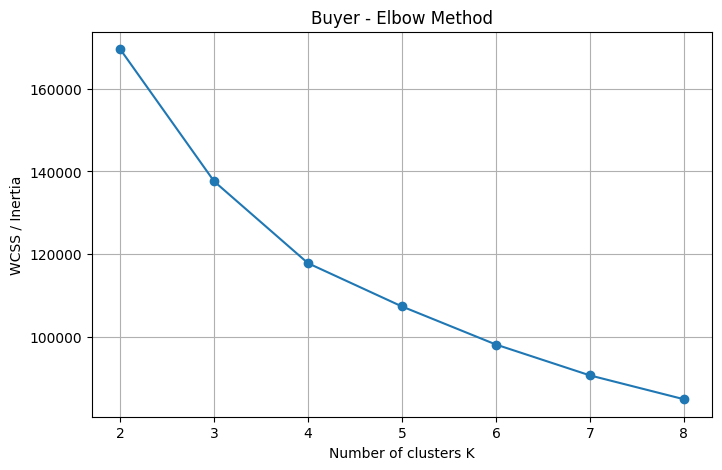

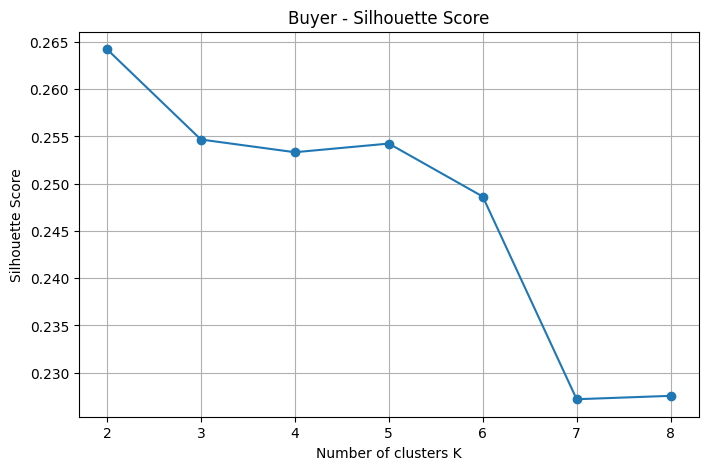

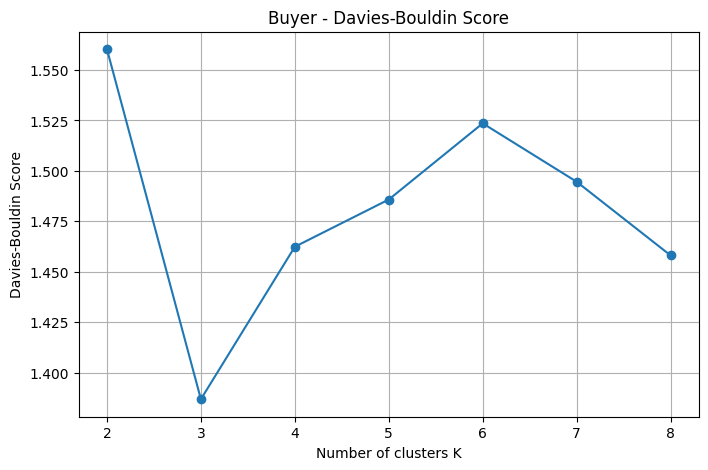

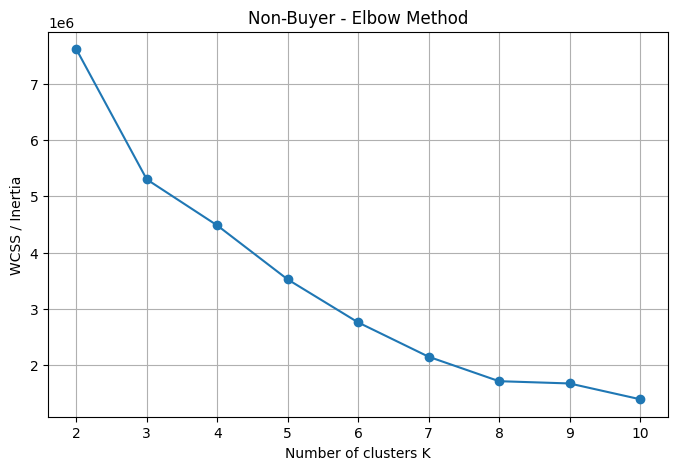

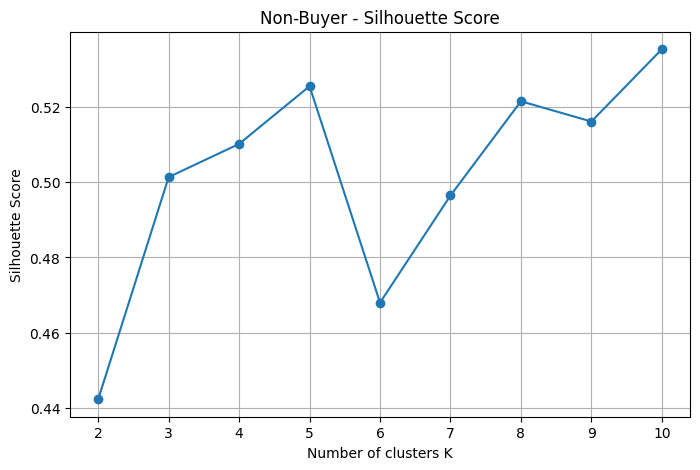

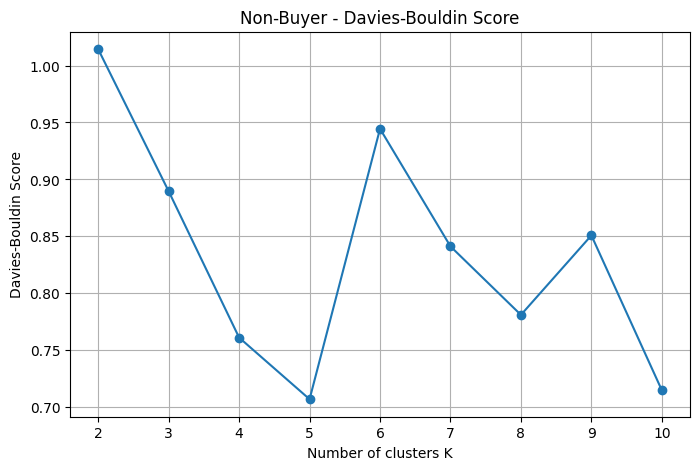

In [51]:
# ============================================================
# PLOT K EVALUATION
# ============================================================

import matplotlib.pyplot as plt

def plot_k_eval(k_eval, title_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(k_eval["k"], k_eval["WCSS_inertia"], marker="o")
    plt.xlabel("Number of clusters K")
    plt.ylabel("WCSS / Inertia")
    plt.title(f"{title_prefix} - Elbow Method")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(k_eval["k"], k_eval["Silhouette"], marker="o")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Silhouette Score")
    plt.title(f"{title_prefix} - Silhouette Score")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(k_eval["k"], k_eval["Davies_Bouldin"], marker="o")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Davies-Bouldin Score")
    plt.title(f"{title_prefix} - Davies-Bouldin Score")
    plt.grid(True)
    plt.show()


plot_k_eval(buyer_k_eval, "Buyer")
plot_k_eval(nonbuyer_k_eval, "Non-Buyer")

In [36]:
# ============================================================
# ELBOW ANALYSIS: WCSS DROP AND RELATIVE IMPROVEMENT
# ============================================================

elbow_df = buyer_k_eval.copy()

elbow_df["WCSS_drop"] = elbow_df["WCSS_inertia"].diff(-1).abs()
elbow_df["WCSS_drop_pct"] = (
    elbow_df["WCSS_drop"] / elbow_df["WCSS_inertia"] * 100
).round(2)

elbow_df["next_WCSS_drop_pct"] = elbow_df["WCSS_drop_pct"].shift(-1)

display(elbow_df)

,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,WCSS_drop,WCSS_drop_pct,next_WCSS_drop_pct
0,2,169545.110164,0.264224,1.560284,5587.135563,31946.005720,18.84,14.39
1,3,137599.104443,0.254670,1.386829,5101.914227,19794.444171,14.39,8.87
2,4,117804.660272,0.253325,1.462389,4773.369738,10450.147121,8.87,8.57
3,5,107354.513152,0.254241,1.485802,4276.202478,9198.830718,8.57,7.60
4,6,98155.682433,0.248635,1.523549,4009.274018,7455.250316,7.60,6.35
5,7,90700.432118,0.227190,1.494608,3811.275270,5761.948534,6.35,NaN
6,8,84938.483583,0.227547,1.458092,3626.701640,NaN,NaN,NaN


In [42]:
BUYER_FINAL_K = 3

In [52]:
# ============================================================
# ELBOW ANALYSIS: WCSS DROP AND RELATIVE IMPROVEMENT
# ============================================================

elbow_df = nonbuyer_k_eval.copy()

elbow_df["WCSS_drop"] = elbow_df["WCSS_inertia"].diff(-1).abs()
elbow_df["WCSS_drop_pct"] = (
    elbow_df["WCSS_drop"] / elbow_df["WCSS_inertia"] * 100
).round(2)

elbow_df["next_WCSS_drop_pct"] = elbow_df["WCSS_drop_pct"].shift(-1)

display(elbow_df)

,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,WCSS_drop,WCSS_drop_pct,next_WCSS_drop_pct
0,2,7.615931e+06,0.442394,1.014333,23333.543986,2.314578e+06,30.39,15.43
1,3,5.301353e+06,0.501298,0.889592,23446.316123,8.182011e+05,15.43,21.42
2,4,4.483152e+06,0.510105,0.761081,20193.534257,9.601601e+05,21.42,21.70
3,5,3.522992e+06,0.525408,0.706961,21318.489180,7.643289e+05,21.70,22.12
4,6,2.758663e+06,0.468001,0.944452,23516.018954,6.101294e+05,22.12,20.23
5,7,2.148533e+06,0.496423,0.841172,26332.047282,4.346616e+05,20.23,2.35
6,8,1.713872e+06,0.521411,0.781031,29573.205406,4.023418e+04,2.35,16.75
7,9,1.673638e+06,0.516037,0.850838,26540.395276,2.803649e+05,16.75,NaN
8,10,1.393273e+06,0.535212,0.714824,28932.140584,NaN,NaN,NaN


In [22]:
NONBUYER_FINAL_K = 4

In [43]:
buyer_final_k = 3
nonbuyer_final_k = 4

In [53]:
# ============================================================
# TRAIN FINAL K-MEANS FOR BUYER AND NON-BUYER GROUPS
# buyer_final_k = 3
# nonbuyer_final_k = 4
# Input:
#   buyer_scored
#   nonbuyer_scored
#   buyer_kmeans_score_features
#   nonbuyer_kmeans_score_features
# Output:
#   buyer_clustered
#   nonbuyer_clustered
#   all_clustered
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, MiniBatchKMeans

buyer_final_k = 3
nonbuyer_final_k = 5


# ============================================================
# 1. Helper function: train final K-Means
# ============================================================

def train_final_kmeans_on_scores(
    df,
    features,
    final_k,
    cluster_col,
    use_minibatch=False,
    batch_size=10000,
    random_state=42
):
    df = df.copy()

    # Keep only existing features
    features = [c for c in features if c in df.columns]

    if len(features) == 0:
        raise ValueError(f"No valid features found for {cluster_col}")

    print(f"\nTraining {cluster_col}")
    print("Final K:", final_k)
    print("Features:", features)

    # Prepare X
    X_raw = df[features].copy()

    for col in features:
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

    # Since all features are 1-5 scores, only impute missing values
    preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    X_ready = preprocess.fit_transform(X_raw)

    # Train K-Means
    if use_minibatch:
        model = MiniBatchKMeans(
            n_clusters=final_k,
            init="k-means++",
            batch_size=batch_size,
            n_init=10,
            random_state=random_state,
            max_iter=300
        )
    else:
        model = KMeans(
            n_clusters=final_k,
            init="k-means++",
            n_init=10,
            random_state=random_state,
            max_iter=300
        )

    df[cluster_col] = model.fit_predict(X_ready)

    # Print distribution
    print("\nCluster counts:")
    display(df[cluster_col].value_counts().sort_index())

    print("\nCluster percentage:")
    display(
        df[cluster_col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    return df, model, preprocess, X_ready, features


# ============================================================
# 2. Train Buyer K-Means
# ============================================================

buyer_clustered, buyer_kmeans_model, buyer_preprocess, X_buyer_ready, buyer_final_features = (
    train_final_kmeans_on_scores(
        df=buyer_scored,
        features=buyer_kmeans_score_features,
        final_k=buyer_final_k,
        cluster_col="Buyer_Cluster",
        use_minibatch=False,
        random_state=42
    )
)


# ============================================================
# 3. Train Non-Buyer K-Means
# ============================================================

nonbuyer_clustered, nonbuyer_kmeans_model, nonbuyer_preprocess, X_nonbuyer_ready, nonbuyer_final_features = (
    train_final_kmeans_on_scores(
        df=nonbuyer_scored,
        features=nonbuyer_kmeans_score_features,
        final_k=nonbuyer_final_k,
        cluster_col="NonBuyer_Cluster",
        use_minibatch=True,
        batch_size=10000,
        random_state=42
    )
)


Training Buyer_Cluster
Final K: 3
Features: ['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'Funnel_score']

Cluster counts:


Buyer_Cluster
0    5020
1    5325
2    3958
Name: count, dtype: int64


Cluster percentage:


Buyer_Cluster
0    35.10
1    37.23
2    27.67
Name: proportion, dtype: float64


Training NonBuyer_Cluster
Final K: 5
Features: ['R_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'Funnel_score', 'Hibernation_score']

Cluster counts:


NonBuyer_Cluster
0     78383
1    460604
2    574771
3     61217
4     83670
Name: count, dtype: int64


Cluster percentage:


NonBuyer_Cluster
0     6.23
1    36.60
2    45.67
3     4.86
4     6.65
Name: proportion, dtype: float64

In [54]:
# ============================================================
# PROFILE BUYER CLUSTERS
# ============================================================

# buyer_profile_cols = buyer_final_features + [
#     "R_recency",
#     "F_frequency",
#     "M_monetary",
#     "M_monetary_log1p",
#     "L_length",
#     "E_engagement",
#     "totals_bounces_mean",
#     "totals_sessionQualityDim_mean",
#     "totals_sessionQualityDim_max",
#     "funnel_depth",
#     "pct_weekend",
#     "pct_evening",
#     "hibernation_flag",
#     "vel_pageviews",
#     "vel_hits",
#     "vel_sessions",
#     "RFM_total",
#     "LRFM_total",
#     "Full_behavior_score",
# ]

buyer_profile_cols = buyer_final_features
buyer_profile_cols = [
    c for c in buyer_profile_cols
    if c in buyer_clustered.columns
]

buyer_cluster_size = (
    buyer_clustered
    .groupby("Buyer_Cluster")
    .size()
    .rename("n_customers")
)

buyer_cluster_pct = (
    buyer_clustered
    .groupby("Buyer_Cluster")
    .size()
    .pipe(lambda s: s / s.sum() * 100)
    .rename("customer_share_pct")
    .round(2)
)

buyer_revenue_share = (
    buyer_clustered
    .groupby("Buyer_Cluster")["M_monetary"]
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .rename("revenue_share_pct")
    .round(2)
)

buyer_profile_median = (
    buyer_clustered
    .groupby("Buyer_Cluster")[buyer_profile_cols]
    .median()
    .round(2)
)

buyer_cluster_summary = (
    pd.concat(
        [
            buyer_cluster_size,
            buyer_cluster_pct,
            buyer_revenue_share,
            buyer_profile_median
        ],
        axis=1
    )
    .reset_index()
)

display(buyer_cluster_summary)

,Buyer_Cluster,n_customers,customer_share_pct,revenue_share_pct,R_score,F_score,M_score,L_score,E_score,Bounce_score,SessionQualityMean_score,Funnel_score
0,0,5020,35.10,61.33,3.0,4.0,4.0,4.0,4.0,2.0,2.0,3.0
1,1,5325,37.23,22.95,2.0,2.0,3.0,1.0,2.0,5.0,1.0,4.0
2,2,3958,27.67,15.72,4.0,2.0,3.0,1.0,2.0,5.0,4.0,4.0


In [26]:
# ============================================================
# CHECK SCORE FEATURES THAT DO NOT DIFFER ACROSS BUYER CLUSTERS
# ============================================================

score_cols = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Weekend_score",
    "Evening_score",
    "Hibernation_score",
    "VelocityPageviews_score",
    "VelocityHits_score",
    "VelocitySessions_score",
]

score_cols = [c for c in score_cols if c in buyer_clustered.columns]

cluster_medians = (
    buyer_clustered
    .groupby("Buyer_Cluster")[score_cols]
    .median()
)

feature_diff = []

for col in score_cols:
    medians = cluster_medians[col]
    feature_diff.append({
        "feature": col,
        "cluster_median_min": medians.min(),
        "cluster_median_max": medians.max(),
        "median_range": medians.max() - medians.min(),
        "unique_cluster_medians": medians.nunique()
    })

feature_diff_df = pd.DataFrame(feature_diff).sort_values(
    ["median_range", "unique_cluster_medians"],
    ascending=[True, True]
)

display(feature_diff_df)

,feature,cluster_median_min,cluster_median_max,median_range,unique_cluster_medians
9,Weekend_score,1.0,1.0,0.0,1
11,Hibernation_score,1.0,1.0,0.0,1
12,VelocityPageviews_score,1.0,1.0,0.0,1
13,VelocityHits_score,1.0,1.0,0.0,1
14,VelocitySessions_score,1.0,1.0,0.0,1
2,M_score,3.0,4.0,1.0,2
8,Funnel_score,3.0,4.0,1.0,2
10,Evening_score,1.0,2.0,1.0,2
0,R_score,2.0,4.0,2.0,3
4,E_score,2.0,4.0,2.0,3


In [27]:
# ============================================================
# CHECK SCORE FEATURES THAT DO NOT DIFFER ACROSS BUYER CLUSTERS
# ============================================================

score_cols = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Weekend_score",
    "Evening_score",
    "Hibernation_score",
    "VelocityPageviews_score",
    "VelocityHits_score",
    "VelocitySessions_score",
]

score_cols = [c for c in score_cols if c in nonbuyer_clustered.columns]

cluster_medians = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")[score_cols]
    .median()
)

feature_diff = []

for col in score_cols:
    medians = cluster_medians[col]
    feature_diff.append({
        "feature": col,
        "cluster_median_min": medians.min(),
        "cluster_median_max": medians.max(),
        "median_range": medians.max() - medians.min(),
        "unique_cluster_medians": medians.nunique()
    })

feature_diff_df = pd.DataFrame(feature_diff).sort_values(
    ["median_range", "unique_cluster_medians"],
    ascending=[True, True]
)

display(feature_diff_df)

,feature,cluster_median_min,cluster_median_max,median_range,unique_cluster_medians
1,F_score,1.0,1.0,0.0,1
2,L_score,1.0,1.0,0.0,1
8,Weekend_score,1.0,1.0,0.0,1
9,Evening_score,1.0,1.0,0.0,1
11,VelocityPageviews_score,1.0,1.0,0.0,1
12,VelocityHits_score,1.0,1.0,0.0,1
13,VelocitySessions_score,1.0,1.0,0.0,1
4,Bounce_score,3.0,5.0,2.0,2
6,SessionQualityMax_score,1.0,3.0,2.0,2
0,R_score,2.0,5.0,3.0,4


In [55]:
# ============================================================
# PROFILE NON-BUYER CLUSTERS
# ============================================================

nonbuyer_profile_cols = nonbuyer_final_features

nonbuyer_profile_cols = [
    c for c in nonbuyer_profile_cols
    if c in nonbuyer_clustered.columns
]

nonbuyer_cluster_size = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")
    .size()
    .rename("n_customers")
)

nonbuyer_cluster_pct = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")
    .size()
    .pipe(lambda s: s / s.sum() * 100)
    .rename("customer_share_pct")
    .round(2)
)

nonbuyer_profile_median = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")[nonbuyer_profile_cols]
    .median()
    .round(2)
)

nonbuyer_cluster_summary = (
    pd.concat(
        [
            nonbuyer_cluster_size,
            nonbuyer_cluster_pct,
            nonbuyer_profile_median
        ],
        axis=1
    )
    .reset_index()
)

display(nonbuyer_cluster_summary)

,NonBuyer_Cluster,n_customers,customer_share_pct,R_score,E_score,Bounce_score,SessionQualityMean_score,Funnel_score,Hibernation_score
0,0,78383,6.23,5.0,1.0,3.0,2.0,1.0,5.0
1,1,460604,36.60,2.0,4.0,5.0,1.0,3.0,1.0
2,2,574771,45.67,3.0,1.0,3.0,1.0,1.0,1.0
3,3,61217,4.86,4.0,5.0,5.0,5.0,5.0,1.0
4,4,83670,6.65,5.0,4.0,5.0,2.0,4.0,5.0


In [56]:
# ============================================================
# ASSIGN BUYER SEGMENT NAME WITH DETAILED BUSINESS LOGIC
# ============================================================

import numpy as np
import pandas as pd

def assign_buyer_segment_name(row):
    # Core RFM / LRFM
    r = row.get("R_score", np.nan)      # Recency: cao = gần đây hơn = tốt hơn
    f = row.get("F_score", np.nan)      # Frequency: cao = nhiều session hơn
    m = row.get("M_score", np.nan)      # Monetary: cao = chi tiêu cao hơn
    l = row.get("L_score", np.nan)      # Length: cao = lịch sử quan hệ dài hơn

    # Engagement / web behavior
    e = row.get("E_score", np.nan)      # Engagement tổng hợp
    bounce = row.get("Bounce_score", np.nan)  # cao = bounce thấp = tốt
    sq = row.get("SessionQualityMean_score", np.nan)
    funnel = row.get("Funnel_score", np.nan)

    # Business contribution
    rev_share = row.get("revenue_share_pct", 0)
    customer_share = row.get("customer_share_pct", 0)

    # ========================================================
    # 1. HIGH-VALUE ENGAGED BUYERS
    # --------------------------------------------------------
    # Logic:
    # - Nhóm này tạo doanh thu vượt tỷ trọng khách hàng
    # - Có frequency cao, monetary cao, length cao, engagement cao
    # - Đây là nhóm cần bảo vệ và phát triển
    # ========================================================
    if (
        rev_share > customer_share
        and f >= 4
        and m >= 4
        and l >= 3
        and e >= 3
    ):
        return "High-Value Engaged Buyers"

    # ========================================================
    # 2. HIGH-VALUE BUYERS WITH FRICTION
    # --------------------------------------------------------
    # Logic:
    # - Vẫn tạo doanh thu vượt tỷ trọng khách hàng
    # - F/M/E tương đối tốt
    # - Nhưng bounce hoặc session quality thấp
    # - Đây là nhóm có giá trị nhưng trải nghiệm có vấn đề
    # ========================================================
    elif (
        rev_share > customer_share
        and f >= 3
        and m >= 3
        and e >= 3
        and (
            bounce <= 2 or sq <= 2
        )
    ):
        return "High-Value Buyers with Friction"

    # ========================================================
    # 3. RECENT QUALITY BUYERS
    # --------------------------------------------------------
    # Logic:
    # - R cao: mới mua/gần đây
    # - F và L thấp: chưa có lịch sử dài, chưa mua/quay lại nhiều
    # - Bounce, session quality, funnel tốt: hành vi phiên chất lượng
    # - Đây là nhóm nên thúc đẩy mua lần 2
    # ========================================================
    elif (
        r >= 4
        and f <= 2
        and l <= 2
        and m >= 3
        and bounce >= 4
        and sq >= 3
        and funnel >= 3
    ):
        return "Recent Quality Buyers"

    # ========================================================
    # 4. RECENT OCCASIONAL BUYERS
    # --------------------------------------------------------
    # Logic:
    # - R cao: mới/gần đây
    # - F thấp: chưa quay lại nhiều
    # - M trung bình trở lên
    # - Nhưng quality/funnel không đủ mạnh để gọi là "quality buyers"
    # ========================================================
    elif (
        r >= 4
        and f <= 2
        and m >= 3
    ):
        return "Recent Occasional Buyers"

    # ========================================================
    # 5. AT-RISK LOW-ACTIVITY BUYERS
    # --------------------------------------------------------
    # Logic:
    # - R thấp: lâu chưa quay lại
    # - F thấp, L thấp, E thấp: hoạt động yếu
    # - M trung bình: từng có giá trị nhưng chưa đủ cao để gọi high-value
    # - Đây là nhóm cần win-back có kiểm soát
    # ========================================================
    elif (
        r <= 2
        and f <= 2
        and l <= 2
        and e <= 2
        and m >= 3
    ):
        return "At-Risk Low-Activity Buyers"

    # ========================================================
    # 6. AT-RISK HIGH-VALUE BUYERS
    # --------------------------------------------------------
    # Logic:
    # - R thấp: lâu chưa quay lại
    # - Nhưng F/M/L cao: từng là khách tốt
    # - Đây là nhóm win-back ưu tiên hơn vì giá trị cao
    # ========================================================
    elif (
        r <= 2
        and m >= 4
        and (
            f >= 3 or l >= 3
        )
    ):
        return "At-Risk High-Value Buyers"

    # ========================================================
    # 7. ENGAGED LOW-SPEND BUYERS
    # --------------------------------------------------------
    # Logic:
    # - Engagement cao
    # - Funnel khá tốt
    # - Nhưng monetary thấp/trung bình thấp
    # - Mục tiêu là upsell/cross-sell để tăng AOV
    # ========================================================
    elif (
        e >= 4
        and funnel >= 3
        and m <= 3
    ):
        return "Engaged Low-Spend Buyers"

    # ========================================================
    # 8. NEW LOW-VALUE BUYERS
    # --------------------------------------------------------
    # Logic:
    # - R cao: mới mua
    # - F thấp, L thấp: mới xuất hiện/chưa có lịch sử
    # - M thấp: giá trị đơn hàng thấp
    # ========================================================
    elif (
        r >= 4
        and f <= 2
        and l <= 2
        and m <= 2
    ):
        return "New Low-Value Buyers"

    # ========================================================
    # 9. LOYAL BUYERS
    # --------------------------------------------------------
    # Logic:
    # - F, M, L, E đều khá tốt
    # - Nhưng revenue share không vượt quá customer share mạnh
    # - Đây là nhóm ổn định, duy trì và phát triển dần
    # ========================================================
    elif (
        f >= 3
        and m >= 3
        and l >= 3
        and e >= 3
    ):
        return "Loyal Buyers"

    # ========================================================
    # 10. REGULAR BUYERS
    # --------------------------------------------------------
    # Logic:
    # - Không rơi vào nhóm đặc biệt nào ở trên
    # - Dùng chiến lược chăm sóc chung
    # ========================================================
    else:
        return "Regular Buyers"


buyer_cluster_summary["Buyer_Segment_Name"] = buyer_cluster_summary.apply(
    assign_buyer_segment_name,
    axis=1
)

buyer_name_map = dict(
    zip(
        buyer_cluster_summary["Buyer_Cluster"],
        buyer_cluster_summary["Buyer_Segment_Name"]
    )
)

buyer_clustered["Buyer_Segment_Name"] = buyer_clustered["Buyer_Cluster"].map(
    buyer_name_map
)

display(
    buyer_cluster_summary[
        [
            "Buyer_Cluster",
            "Buyer_Segment_Name",
            "n_customers",
            "customer_share_pct",
            "revenue_share_pct",
            "R_score",
            "F_score",
            "M_score",
            "L_score",
            "E_score",
            "Bounce_score",
            "SessionQualityMean_score",
            "Funnel_score",
        ]
    ]
)

,Buyer_Cluster,Buyer_Segment_Name,n_customers,customer_share_pct,revenue_share_pct,R_score,F_score,M_score,L_score,E_score,Bounce_score,SessionQualityMean_score,Funnel_score
0,0,High-Value Engaged Buyers,5020,35.10,61.33,3.0,4.0,4.0,4.0,4.0,2.0,2.0,3.0
1,1,At-Risk Low-Activity Buyers,5325,37.23,22.95,2.0,2.0,3.0,1.0,2.0,5.0,1.0,4.0
2,2,Recent Quality Buyers,3958,27.67,15.72,4.0,2.0,3.0,1.0,2.0,5.0,4.0,4.0


In [58]:
# ============================================================
# ASSIGN NON-BUYER SEGMENT NAME WITH DETAILED BUSINESS LOGIC
# ============================================================

import numpy as np
import pandas as pd

def assign_nonbuyer_segment_name(row):
    # Core behavior
    r = row.get("R_score", np.nan)      # cao = gần đây hơn
    f = row.get("F_score", np.nan)      # cao = nhiều session hơn
    l = row.get("L_score", np.nan)      # cao = vòng đời dài hơn

    # Engagement / web behavior
    e = row.get("E_score", np.nan)      # engagement tổng
    bounce = row.get("Bounce_score", np.nan)  # cao = ít bounce = tốt
    sq = row.get("SessionQualityMean_score", np.nan)
    funnel = row.get("Funnel_score", np.nan)
    h = row.get("Hibernation_score", np.nan)  # cao = không ngủ đông / active hơn nếu bạn chấm lower_better cho flag

    # ========================================================
    # 1. HOT PROSPECTS
    # --------------------------------------------------------
    # Logic:
    # - Khách còn rất recent
    # - Engagement rất cao
    # - Ít bounce
    # - Session quality cao
    # - Đi tương đối sâu funnel
    # => Đây là nhóm non-buyer có khả năng chuyển đổi cao nhất.
    # ========================================================
    if (
        r >= 4
        and e >= 4
        and bounce >= 4
        and sq >= 4
        and funnel >= 4
    ):
        return "Hot Prospects"

    # ========================================================
    # 2. WARM PROSPECTS
    # --------------------------------------------------------
    # Logic:
    # - Khách còn recent
    # - Có engagement hoặc funnel khá
    # - Chưa đủ mạnh để gọi là Hot Prospects
    # => Nên nuôi dưỡng/chuyển đổi nhẹ.
    # ========================================================
    elif (
        r >= 4
        and (
            e >= 3
            or funnel >= 3
            or sq >= 3
        )
    ):
        return "Warm Prospects"

    # ========================================================
    # 3. NEW LOW-INTENT VISITORS
    # --------------------------------------------------------
    # Logic:
    # - Khách mới/gần đây
    # - Nhưng engagement thấp, funnel thấp, quality thấp
    # - Có thể chỉ mới ghé qua, chưa có intent rõ
    # => Không nên đốt ngân sách retargeting mạnh.
    # ========================================================
    elif (
        r >= 4
        and e <= 2
        and funnel <= 2
        and sq <= 2
    ):
        return "New Low-Intent Visitors"

    # ========================================================
    # 4. DORMANT ENGAGED NON-BUYERS
    # --------------------------------------------------------
    # Logic:
    # - R thấp: lâu chưa quay lại
    # - Nhưng trước đó từng engagement cao / funnel tương đối
    # - Bounce tốt cho thấy phiên không quá xấu
    # => Nhóm này từng có tín hiệu quan tâm, nên reactivation.
    # ========================================================
    elif (
        r <= 2
        and e >= 3
        and bounce >= 4
        and funnel >= 3
    ):
        return "Dormant Engaged Non-Buyers"

    # ========================================================
    # 5. DORMANT HIGH-QUALITY RESEARCHERS
    # --------------------------------------------------------
    # Logic:
    # - Không recent
    # - Nhưng session quality/funnel tốt
    # - Có thể từng nghiên cứu sản phẩm nhưng chưa mua
    # => Nên nhắc lại bằng proof points, reviews, comparison.
    # ========================================================
    elif (
        r <= 2
        and sq >= 4
        and funnel >= 3
    ):
        return "Dormant High-Quality Researchers"

    # ========================================================
    # 6. BROWSERS WITH FRICTION
    # --------------------------------------------------------
    # Logic:
    # - Engagement cao nhưng bounce thấp điểm hoặc funnel yếu
    # - Họ quan tâm nhưng trải nghiệm/landing/UX có vấn đề
    # => Cần tối ưu landing page, content, CTA.
    # ========================================================
    elif (
        e >= 4
        and (
            bounce <= 2
            or funnel <= 2
        )
    ):
        return "Browsers with Friction"

    # ========================================================
    # 7. DORMANT LOW-INTENT NON-BUYERS
    # --------------------------------------------------------
    # Logic:
    # - Không recent
    # - Engagement thấp
    # - Funnel thấp
    # - Session quality thấp
    # => Nhóm ưu tiên thấp, chỉ nên nuôi dưỡng chi phí thấp.
    # ========================================================
    elif (
        r <= 2
        and e <= 2
        and funnel <= 2
        and sq <= 2
    ):
        return "Dormant Low-Intent Non-Buyers"

    # ========================================================
    # 8. PERSISTENT NON-BUYERS
    # --------------------------------------------------------
    # Logic:
    # - F hoặc L cao, nghĩa là có quay lại/lịch sử dài
    # - Nhưng vẫn chưa mua
    # => Có thể cần phân tích rào cản giá, trust, product-fit.
    # ========================================================
    elif (
        f >= 3
        or l >= 3
    ):
        return "Persistent Non-Buyers"

    # ========================================================
    # 9. GENERAL NON-BUYERS
    # --------------------------------------------------------
    # Logic:
    # - Không rơi vào nhóm hành vi đặc biệt nào
    # => Nuôi dưỡng chung, không ưu tiên ngân sách cao.
    # ========================================================
    else:
        return "General Non-Buyers"


nonbuyer_cluster_summary["NonBuyer_Segment_Name"] = (
    nonbuyer_cluster_summary.apply(assign_nonbuyer_segment_name, axis=1)
)

nonbuyer_name_map = dict(
    zip(
        nonbuyer_cluster_summary["NonBuyer_Cluster"],
        nonbuyer_cluster_summary["NonBuyer_Segment_Name"]
    )
)

nonbuyer_clustered["NonBuyer_Segment_Name"] = (
    nonbuyer_clustered["NonBuyer_Cluster"].map(nonbuyer_name_map)
)

display(
    nonbuyer_cluster_summary[
        [
            "NonBuyer_Cluster",
            "NonBuyer_Segment_Name",
            "n_customers",
            "customer_share_pct",
            "R_score",
            "E_score",
            "Bounce_score",
            "SessionQualityMean_score",
            "Funnel_score",
            "Hibernation_score",
        ]
    ]
)

,NonBuyer_Cluster,NonBuyer_Segment_Name,n_customers,customer_share_pct,R_score,E_score,Bounce_score,SessionQualityMean_score,Funnel_score,Hibernation_score
0,0,New Low-Intent Visitors,78383,6.23,5.0,1.0,3.0,2.0,1.0,5.0
1,1,Dormant Engaged Non-Buyers,460604,36.60,2.0,4.0,5.0,1.0,3.0,1.0
2,2,General Non-Buyers,574771,45.67,3.0,1.0,3.0,1.0,1.0,1.0
3,3,Hot Prospects,61217,4.86,4.0,5.0,5.0,5.0,5.0,1.0
4,4,Warm Prospects,83670,6.65,5.0,4.0,5.0,2.0,4.0,5.0


In [59]:
# ============================================================
# FINAL CUSTOMER-LEVEL SEGMENTATION OUTPUT
# Original unscored features + Buyer/Non-Buyer + Cluster labels
# Based on final Buyer K=3 and Non-Buyer K=5
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# 1. Manual final segment name mapping
# ============================================================

buyer_final_name_map = {
    0: "High-Value Engaged Buyers",
    1: "At-Risk Low-Activity Buyers",
    2: "Recent Quality Buyers",
}

nonbuyer_final_name_map = {
    0: "New Low-Intent Visitors",
    1: "Dormant Engaged Non-Buyers",
    2: "General Non-Buyers",
    3: "Hot Prospects",
    4: "Warm Prospects",
}


# ============================================================
# 2. Strategy mapping
# ============================================================

final_strategy_map = {
    # ----------------------------
    # Buyer segments
    # ----------------------------
    "High-Value Engaged Buyers": {
        "Objective": "Protect and grow the main revenue-generating buyer segment",
        "Recommended_Strategy": "Loyalty benefits, personalized cross-sell, bundles, early access, premium service",
        "Avoid": "Avoid broad deep discounts because this group already contributes high revenue",
        "KPI": "Revenue retention, repeat purchase rate, AOV, cross-sell conversion",
    },

    "At-Risk Low-Activity Buyers": {
        "Objective": "Reactivate buyers with weak recent activity",
        "Recommended_Strategy": "Win-back email, low-cost remarketing, product/category reminders, controlled reactivation offer",
        "Avoid": "Avoid high CAC campaigns and expensive incentives",
        "KPI": "Reactivation rate, return visit rate, recovered revenue, cost per reactivated buyer",
    },

    "Recent Quality Buyers": {
        "Objective": "Convert recent quality buyers into repeat buyers",
        "Recommended_Strategy": "Post-purchase onboarding, second-purchase incentive, recommendations, cross-sell follow-up",
        "Avoid": "Avoid treating them as loyal buyers too early",
        "KPI": "Second purchase rate, time to next purchase, repeat buyer conversion, email CTR",
    },

    # ----------------------------
    # Non-Buyer segments
    # ----------------------------
    "Hot Prospects": {
        "Objective": "Convert high-intent non-buyers into first-time buyers",
        "Recommended_Strategy": "Prioritized retargeting, first-purchase incentive, personalized recommendation, abandoned journey reminder",
        "Avoid": "Avoid generic awareness campaigns because this group already shows strong intent",
        "KPI": "First purchase conversion rate, add-to-cart rate, retargeting ROAS, CAC",
    },

    "Warm Prospects": {
        "Objective": "Nurture interested non-buyers and move them closer to purchase",
        "Recommended_Strategy": "Product education, comparison guides, personalized recommendations, light retargeting, email capture",
        "Avoid": "Avoid heavy discounting before purchase intent is clear",
        "KPI": "Product view depth, return visit rate, add-to-cart rate, email CTR, assisted conversion",
    },

    "New Low-Intent Visitors": {
        "Objective": "Build awareness and collect more behavioral signals",
        "Recommended_Strategy": "Low-cost nurturing, homepage personalization, content recommendation, newsletter or email capture",
        "Avoid": "Avoid aggressive discounting or expensive retargeting too early",
        "KPI": "Second session rate, return visit rate, email signup rate, engagement growth",
    },

    "Dormant Engaged Non-Buyers": {
        "Objective": "Reactivate previously engaged visitors",
        "Recommended_Strategy": "Win-back campaign, product/category reminder, limited-time return offer, content addressing purchase barriers",
        "Avoid": "Avoid high-cost acquisition campaigns; use controlled reactivation",
        "KPI": "Return visit rate, reactivation rate, first purchase rate, cost per reactivated visitor",
    },

    "General Non-Buyers": {
        "Objective": "Maintain low-cost engagement or suppress from expensive campaigns",
        "Recommended_Strategy": "General nurturing campaign, seasonal content, low-cost remarketing only",
        "Avoid": "Avoid high CAC spending and deep personalization investment",
        "KPI": "CTR, return visit rate, cost per engaged user, low-cost conversion",
    },
}


# ============================================================
# 3. Apply final names to clustered data
# ============================================================

buyer_final = buyer_clustered.copy()
nonbuyer_final = nonbuyer_clustered.copy()

buyer_final["Main_Segment"] = "Buyer"
nonbuyer_final["Main_Segment"] = "Non-Buyer"

buyer_final["Buyer_Segment_Name"] = buyer_final["Buyer_Cluster"].map(
    buyer_final_name_map
)

nonbuyer_final["NonBuyer_Segment_Name"] = nonbuyer_final["NonBuyer_Cluster"].map(
    nonbuyer_final_name_map
)

buyer_final["Final_Cluster"] = "Buyer_" + buyer_final["Buyer_Cluster"].astype(str)
nonbuyer_final["Final_Cluster"] = "NonBuyer_" + nonbuyer_final["NonBuyer_Cluster"].astype(str)

buyer_final["Final_Cluster_Name"] = buyer_final["Buyer_Segment_Name"]
nonbuyer_final["Final_Cluster_Name"] = nonbuyer_final["NonBuyer_Segment_Name"]


# ============================================================
# 4. Create label table
# ============================================================

buyer_label_cols = [
    "fullVisitorId",
    "Main_Segment",
    "Buyer_Cluster",
    "Final_Cluster",
    "Final_Cluster_Name",
]

nonbuyer_label_cols = [
    "fullVisitorId",
    "Main_Segment",
    "NonBuyer_Cluster",
    "Final_Cluster",
    "Final_Cluster_Name",
]

buyer_labels = buyer_final[
    [c for c in buyer_label_cols if c in buyer_final.columns]
].copy()

nonbuyer_labels = nonbuyer_final[
    [c for c in nonbuyer_label_cols if c in nonbuyer_final.columns]
].copy()

cluster_labels = pd.concat(
    [buyer_labels, nonbuyer_labels],
    axis=0,
    ignore_index=True
)

cluster_labels = cluster_labels.drop_duplicates(
    subset=["fullVisitorId"],
    keep="first"
)

print("cluster_labels shape:", cluster_labels.shape)
print("unique customers in labels:", cluster_labels["fullVisitorId"].nunique())

display(cluster_labels.head())

cluster_labels shape: (1272948, 6)
unique customers in labels: 1272948


,fullVisitorId,Main_Segment,Buyer_Cluster,Final_Cluster,Final_Cluster_Name,NonBuyer_Cluster
0,0000213131142648941,Buyer,1.0,Buyer_1,At-Risk Low-Activity Buyers,NaN
1,0000384434116640351,Buyer,2.0,Buyer_2,Recent Quality Buyers,NaN
2,0001376836098133431,Buyer,2.0,Buyer_2,Recent Quality Buyers,NaN
3,0002871498069867123,Buyer,1.0,Buyer_1,At-Risk Low-Activity Buyers,NaN
4,0003450834640354121,Buyer,0.0,Buyer_0,High-Value Engaged Buyers,NaN


In [60]:
# ============================================================
# 5. Select original unscored customer-level features
# ============================================================

exclude_keywords = [
    "_score",
    "RFM_score",
    "RFM_total",
    "LRFM_total",
    "RF_total",
    "LRF_total",
    "RF2M_total",
    "LRF2M_total",
    "L2RF2M_total",
    "Full_behavior_score",
    "Buyer_Cluster",
    "NonBuyer_Cluster",
    "Final_Cluster",
    "Buyer_Segment_Name",
    "NonBuyer_Segment_Name",
    "Final_Cluster_Name",
]

original_cols = []

for col in all_seg.columns:
    if not any(key in col for key in exclude_keywords):
        original_cols.append(col)

if "fullVisitorId" not in original_cols:
    original_cols = ["fullVisitorId"] + original_cols

customer_original = all_seg[original_cols].copy()

print("Original unscored columns:", len(original_cols))
print(original_cols)
display(customer_original.head())

Original unscored columns: 60
['fullVisitorId', 'visitId_count', 'visitId_nunique', 'visitNumber_max', 'totals_hits_sum', 'totals_hits_mean', 'totals_hits_max', 'totals_pageviews_sum', 'totals_pageviews_mean', 'totals_pageviews_max', 'totals_timeOnSite_sum', 'totals_timeOnSite_mean', 'totals_timeOnSite_max', 'totals_bounces_mean', 'totals_sessionQualityDim_mean', 'totals_sessionQualityDim_max', 'transactionRevenue_sum', 'transactionRevenue_mean', 'transactionRevenue_max', 'totals_transactions_sum', 'device_isMobile_mean', 'funnel_depth', 'pct_weekend', 'pct_evening', 'city_nunique', 'country_nunique', 'source_nunique', 'medium_nunique', 'channel_nunique', 'browser_nunique', 'os_nunique', 'first_visit_date', 'last_visit_date', 'recency_days', 'lifetime_days', 'visit_count', 'hibernation_flag', 'vel_pageviews', 'vel_hits', 'vel_sessions', 'F2_purchase_frequency', 'first_purchase_date', 'last_purchase_date', 'total_purchase_revenue', 'L2_purchase_gap_days', 'F2_purchase_frequency_log1p', 

,fullVisitorId,visitId_count,visitId_nunique,visitNumber_max,totals_hits_sum,totals_hits_mean,totals_hits_max,totals_pageviews_sum,totals_pageviews_mean,totals_pageviews_max,...,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,E_engagement,Buyer_Flag,Buyer_Segment,Buyer_Strategy
0,0000010278554503158,1,1,1,11,11.0,11,8,8.0,8,...,0.0,0,7,8,11,194,9.955131,0,Non-Buyer,Activation / Conversion / First purchase
1,0000020424342248747,1,1,1,17,17.0,17,13,13.0,13,...,0.0,0,7,13,17,297,11.226523,0,Non-Buyer,Activation / Conversion / First purchase
2,0000027376579751715,1,1,1,6,6.0,6,5,5.0,5,...,0.0,0,7,5,6,49,7.649693,0,Non-Buyer,Activation / Conversion / First purchase
3,0000039460501403861,1,1,1,2,2.0,2,2,2.0,2,...,0.0,0,7,2,2,99,6.802395,0,Non-Buyer,Activation / Conversion / First purchase
4,0000040862739425590,2,2,2,5,2.5,3,5,2.5,3,...,0.0,0,7,5,5,49,7.495542,0,Non-Buyer,Activation / Conversion / First purchase


In [61]:
# ============================================================
# 6. Merge original features with final cluster labels
# ============================================================

customer_segmentation_output = customer_original.merge(
    cluster_labels,
    on="fullVisitorId",
    how="left"
)

# Nếu Buyer_Segment đã có trong all_seg thì giữ lại.
# Nếu chưa có thì dùng Main_Segment.
if "Buyer_Segment" not in customer_segmentation_output.columns:
    customer_segmentation_output["Buyer_Segment"] = customer_segmentation_output["Main_Segment"]

# Add strategy columns
for col in ["Objective", "Recommended_Strategy", "Avoid", "KPI"]:
    customer_segmentation_output[col] = customer_segmentation_output["Final_Cluster_Name"].apply(
        lambda x: final_strategy_map.get(x, {}).get(col, np.nan)
    )

# Reorder important columns to the front
front_cols = [
    "fullVisitorId",
    "Buyer_Flag",
    "Buyer_Segment",
    "Main_Segment",
    "Buyer_Cluster",
    "NonBuyer_Cluster",
    "Final_Cluster",
    "Final_Cluster_Name",
    "Objective",
    "Recommended_Strategy",
    "Avoid",
    "KPI",
]

front_cols = [
    c for c in front_cols
    if c in customer_segmentation_output.columns
]

remaining_cols = [
    c for c in customer_segmentation_output.columns
    if c not in front_cols
]

customer_segmentation_output = customer_segmentation_output[
    front_cols + remaining_cols
]

print("Final customer segmentation output shape:", customer_segmentation_output.shape)
print("Unique customers:", customer_segmentation_output["fullVisitorId"].nunique())

display(customer_segmentation_output.head())

Final customer segmentation output shape: (1272948, 69)
Unique customers: 1272948


,fullVisitorId,Buyer_Flag,Buyer_Segment,Main_Segment,Buyer_Cluster,NonBuyer_Cluster,Final_Cluster,Final_Cluster_Name,Objective,Recommended_Strategy,...,F_frequency,M_monetary,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,E_engagement,Buyer_Strategy
0,0000010278554503158,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,1,0.0,0.0,0,7,8,11,194,9.955131,Activation / Conversion / First purchase
1,0000020424342248747,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,1,0.0,0.0,0,7,13,17,297,11.226523,Activation / Conversion / First purchase
2,0000027376579751715,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,1,0.0,0.0,0,7,5,6,49,7.649693,Activation / Conversion / First purchase
3,0000039460501403861,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,1,0.0,0.0,0,7,2,2,99,6.802395,Activation / Conversion / First purchase
4,0000040862739425590,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,2,0.0,0.0,0,7,5,5,49,7.495542,Activation / Conversion / First purchase


In [62]:
# ============================================================
# 8. Save full output
# ============================================================

OUTPUT_DIR = Path(r"D:\data_driven_marketing\data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

customer_segmentation_output.to_pickle(
    OUTPUT_DIR / "customer_segmentation_output_final.pkl"
)

customer_segmentation_output.to_csv(
    OUTPUT_DIR / "customer_segmentation_output_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved full output:")
print(OUTPUT_DIR / "customer_segmentation_output_final.pkl")
print(OUTPUT_DIR / "customer_segmentation_output_final.csv")

Saved full output:
D:\data_driven_marketing\data\customer_segmentation_output_final.pkl
D:\data_driven_marketing\data\customer_segmentation_output_final.csv


In [63]:
# ============================================================
# 9. Save dashboard-friendly output
# ============================================================

dashboard_cols = [
    "fullVisitorId",
    "Buyer_Flag",
    "Buyer_Segment",
    "Main_Segment",
    "Buyer_Cluster",
    "NonBuyer_Cluster",
    "Final_Cluster",
    "Final_Cluster_Name",
    "Objective",
    "Recommended_Strategy",
    "Avoid",
    "KPI",

    # Core original unscored features
    "R_recency",
    "F_frequency",
    "M_monetary",
    "M_monetary_log1p",
    "L_length",

    # Purchase behavior if available
    "F2_purchase_frequency",
    "F2_purchase_frequency_log1p",
    "L2_purchase_gap_days",
    "Repeat_Buyer_Flag",

    # Engagement original values
    "E_pageviews",
    "E_hits",
    "E_timeOnSite",
    "E_engagement",

    # Web behavior
    "totals_bounces_mean",
    "totals_sessionQualityDim_mean",
    "totals_sessionQualityDim_max",
    "funnel_depth",

    # Time/lifecycle
    "pct_weekend",
    "pct_evening",
    "hibernation_flag",
    "vel_pageviews",
    "vel_hits",
    "vel_sessions",

    # Dates if available
    "first_visit_date",
    "last_visit_date",
    "first_purchase_date",
    "last_purchase_date",
]

dashboard_cols = [
    c for c in dashboard_cols
    if c in customer_segmentation_output.columns
]

customer_segmentation_dashboard = customer_segmentation_output[
    dashboard_cols
].copy()

customer_segmentation_dashboard.to_pickle(
    OUTPUT_DIR / "customer_segmentation_dashboard_final.pkl"
)

customer_segmentation_dashboard.to_csv(
    OUTPUT_DIR / "customer_segmentation_dashboard_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dashboard output shape:", customer_segmentation_dashboard.shape)

print("Saved dashboard output:")
print(OUTPUT_DIR / "customer_segmentation_dashboard_final.pkl")
print(OUTPUT_DIR / "customer_segmentation_dashboard_final.csv")

display(customer_segmentation_dashboard.head())

Dashboard output shape: (1272948, 39)
Saved dashboard output:
D:\data_driven_marketing\data\customer_segmentation_dashboard_final.pkl
D:\data_driven_marketing\data\customer_segmentation_dashboard_final.csv


,fullVisitorId,Buyer_Flag,Buyer_Segment,Main_Segment,Buyer_Cluster,NonBuyer_Cluster,Final_Cluster,Final_Cluster_Name,Objective,Recommended_Strategy,...,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,first_visit_date,last_visit_date,first_purchase_date,last_purchase_date
0,0000010278554503158,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,0.0,0.0,1,1.0,1.0,1.0,2016-10-20,2016-10-20,NaT,NaT
1,0000020424342248747,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,0.0,0.0,1,1.0,1.0,1.0,2016-11-30,2016-11-30,NaT,NaT
2,0000027376579751715,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,1.0,0.0,1,1.0,1.0,1.0,2017-02-11,2017-02-11,NaT,NaT
3,0000039460501403861,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,0.0,0.0,1,1.0,1.0,1.0,2017-03-27,2017-03-27,NaT,NaT
4,0000040862739425590,0,Non-Buyer,Non-Buyer,NaN,1.0,NonBuyer_1,Dormant Engaged Non-Buyers,Reactivate previously engaged visitors,"Win-back campaign, product/category reminder, ...",...,1.0,0.0,1,1.0,1.0,1.0,2017-02-11,2017-02-11,NaT,NaT
